# 1. 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np

from datetime import datetime

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset')

import warnings
warnings.filterwarnings('ignore')

# 2. 아파트 매매 거래량

In [2]:
# 초기값 설정
start_year, start_month = 2010, 6
end_year, end_month = 2024, 6

# 1년 단위 파일명 리스트 컴프리헨션 생성
date_index_lst = [
    f"{year:04}{start_month:02}_{year+1:04}{start_month-1:02}"
    for year in range(start_year, end_year)
]

# 마지막 파일 추가 (202406_202412)
date_index_lst.append("202406_202412")

# date_index_lst = date_index_lst[10:]
date_index_lst = date_index_lst[11:]
date_index_lst

['202106_202205', '202206_202305', '202306_202405', '202406_202412']

In [3]:
# 행정구 / 일 단위 데이터셋 생성
apt_volume_df_lst = []
for date_index in tqdm(date_index_lst):

    print(date_index)

    origin_apt_volume_df = pd.read_excel(f'C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/apt_volume/apt_purchase_volume_{date_index}.xlsx', header=12)

    # 거래일자
    origin_apt_volume_df['date'] = origin_apt_volume_df['계약년월'].astype(str) + origin_apt_volume_df['계약일'].astype(str)
    origin_apt_volume_df['date'] = pd.to_datetime(origin_apt_volume_df['date'], format='%Y%m%d')

    # 지역
    origin_apt_volume_df['region'] = origin_apt_volume_df['시군구'].map(lambda x: ' '.join(x.split(' ')[:2]))
    
    # 거래금액
    origin_apt_volume_df['거래금액(만원)'] = origin_apt_volume_df['거래금액(만원)'].map(lambda x: int(x.replace(',', '')) * 10000)

    # 계약 해지 여부
    origin_apt_volume_df['is_trade_canceled'] = origin_apt_volume_df['해제사유발생일'].map(lambda x: 1 if x != '-' else 0)

    # 해제사유발생일 도달 기간
    origin_apt_volume_df['해제사유발생일'] = pd.to_numeric(origin_apt_volume_df['해제사유발생일'], errors='coerce')
    origin_apt_volume_df['해제사유발생일'] = pd.to_datetime(origin_apt_volume_df['해제사유발생일'], format='%Y%m%d', errors='coerce')
    origin_apt_volume_df['trade_canceled_duration'] = (origin_apt_volume_df['해제사유발생일'] - origin_apt_volume_df['date']).dt.days

    # 등기구분
    origin_apt_volume_df['is_trade_registered'] = origin_apt_volume_df['등기일자'].map(lambda x: 1 if x != '-' else 0)

    # 등기일자
    origin_apt_volume_df['등기일자'] = pd.to_datetime(origin_apt_volume_df['등기일자'], format='%y.%m.%d', errors='coerce')
    origin_apt_volume_df['trade_registered_duration'] = (origin_apt_volume_df['등기일자'] - origin_apt_volume_df['date']).dt.days

    # 전용면적 컬럼명 변경
    origin_apt_volume_df = origin_apt_volume_df.rename(columns={'전용면적(㎡)':'size'})

    apt_volume_df_lst.append(origin_apt_volume_df)

apt_volume_df = pd.concat(apt_volume_df_lst, ignore_index=True)
apt_volume_df

  0%|          | 0/4 [00:00<?, ?it/s]

202106_202205


 25%|██▌       | 1/4 [00:15<00:46, 15.59s/it]

202206_202305


 50%|█████     | 2/4 [00:27<00:26, 13.38s/it]

202306_202405


 75%|███████▌  | 3/4 [00:52<00:18, 18.67s/it]

202406_202412


100%|██████████| 4/4 [01:12<00:00, 18.09s/it]


,NO,시군구,번지,본번,부번,단지명,size,계약년월,계약일,거래금액(만원),...,거래유형,중개사소재지,등기일자,주택유형,date,region,is_trade_canceled,trade_canceled_duration,is_trade_registered,trade_registered_duration
0,1,서울특별시 노원구 공릉동,707,707,0,시영2단지(라이프)아파트,34.4400,202205,31,438000000,...,중개거래,서울 노원구,NaT,아파트,2022-05-31,서울특별시 노원구,0,NaN,0,NaN
1,2,서울특별시 용산구 원효로1가,133-3,133,3,리첸시아용산A,198.3200,202205,31,4500000000,...,중개거래,서울 강남구,NaT,아파트,2022-05-31,서울특별시 용산구,0,NaN,0,NaN
2,3,서울특별시 강서구 화곡동,897-2,897,2,루체비스타,24.6700,202205,31,220000000,...,중개거래,서울 강서구,NaT,아파트,2022-05-31,서울특별시 강서구,0,NaN,0,NaN
3,4,서울특별시 마포구 아현동,777,777,0,마포래미안푸르지오4단지,84.8919,202205,31,1875000000,...,중개거래,서울 마포구,NaT,아파트,2022-05-31,서울특별시 마포구,0,NaN,0,NaN
4,5,서울특별시 성동구 응봉동,15,15,0,대림강변타운,84.4200,202205,31,1630000000,...,중개거래,서울 성동구,NaT,아파트,2022-05-31,서울특별시 성동구,0,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126023,37129,서울특별시 성동구 금호동1가,633,633,0,벽산,84.8200,202406,1,1125000000,...,중개거래,서울 성동구,2024-08-02,아파트,2024-06-01,서울특별시 성동구,0,NaN,1,62.0
126024,37130,서울특별시 성동구 옥수동,528,528,0,옥수파크힐스101동~116동,84.5100,202406,1,1870000000,...,중개거래,서울 성동구,2024-08-21,아파트,2024-06-01,서울특별시 성동구,0,NaN,1,81.0
126025,37131,서울특별시 성동구 옥수동,528-1,528,1,옥수파크힐스117동~125동,59.9100,202406,1,1570000000,...,중개거래,"서울 서초구, 서울 성동구",2024-08-13,아파트,2024-06-01,서울특별시 성동구,0,NaN,1,73.0
126026,37132,서울특별시 성북구 종암동,133,133,0,래미안세레니티,84.9900,202406,1,870000000,...,직거래,-,2024-09-30,아파트,2024-06-01,서울특별시 성북구,0,NaN,1,121.0


In [4]:
len(apt_volume_df.query("date >= '2021-11-01'"))

107906

In [5]:
# 거래 발생 여부 컬럼 추가
apt_volume_df['is_trade'] = 1

In [6]:
# 날짜 펼치기
date_range = pd.date_range(start="2021-06-01", end="2024-12-31", freq="D")
daily_date_df = pd.DataFrame({"date": date_range})

districts = apt_volume_df["region"].unique()

filled_apt_volume_df_lst = []
for gu in districts:

    # 해당 구 데이터만 필터링
    gu_df = apt_volume_df[apt_volume_df["region"] == gu]

    # 날짜 DataFrame과 outer merge
    merged = pd.merge(daily_date_df, gu_df, on="date", how="left")

    # 'region' 결측값 채우기
    merged["region"] = gu

    zero_fill_cols = ['거래금액(만원)', 'is_trade', 'is_trade_canceled', 'is_trade_registered']
    for col in zero_fill_cols:
        if col in merged.columns:
            merged[col] = merged[col].fillna(0)

    forward_fill_cols = ['NO', '시군구', '번지', '본번', '부번', '단지명', 'size',
                         '동', '층', '건축년도', '도로명', '주택유형', '거래유형']
    for col in forward_fill_cols:
        if col in merged.columns:
            merged[col] = merged[col].fillna(method='ffill').fillna(method='bfill')

    # 리스트에 저장
    filled_apt_volume_df_lst.append(merged)

# 5. 구별 데이터 모두 합치기
filled_apt_volume_df = pd.concat(filled_apt_volume_df_lst, ignore_index=True)
filled_apt_volume_df

,date,NO,시군구,번지,본번,부번,단지명,size,계약년월,계약일,...,거래유형,중개사소재지,등기일자,주택유형,region,is_trade_canceled,trade_canceled_duration,is_trade_registered,trade_registered_duration,is_trade
0,2021-06-01,27876.0,서울특별시 노원구 상계동,1269,1269.0,0.0,수락파크빌,114.82,202106.0,1.0,...,-,-,NaT,아파트,서울특별시 노원구,0.0,NaN,0.0,NaN,1.0
1,2021-06-01,27888.0,서울특별시 노원구 공릉동,757,757.0,0.0,우국리더스빌,49.60,202106.0,1.0,...,-,-,NaT,아파트,서울특별시 노원구,0.0,NaN,0.0,NaN,1.0
2,2021-06-01,27891.0,서울특별시 노원구 월계동,923,923.0,0.0,초안1,49.60,202106.0,1.0,...,-,-,NaT,아파트,서울특별시 노원구,0.0,NaN,0.0,NaN,1.0
3,2021-06-01,27893.0,서울특별시 노원구 월계동,923,923.0,0.0,초안1,49.60,202106.0,1.0,...,-,-,NaT,아파트,서울특별시 노원구,1.0,167.0,0.0,NaN,1.0
4,2021-06-01,27896.0,서울특별시 노원구 월계동,781,781.0,0.0,청백4,49.77,202106.0,1.0,...,-,-,NaT,아파트,서울특별시 노원구,0.0,NaN,0.0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132460,2024-12-29,456.0,서울특별시 금천구 시흥동,1010,1010.0,0.0,벽산,84.99,NaN,NaN,...,중개거래,NaN,NaT,아파트,서울특별시 금천구,0.0,NaN,0.0,NaN,0.0
132461,2024-12-30,158.0,서울특별시 금천구 가산동,769,769.0,0.0,두산,134.95,202412.0,30.0,...,중개거래,서울 금천구,NaT,아파트,서울특별시 금천구,0.0,NaN,0.0,NaN,1.0
132462,2024-12-30,164.0,서울특별시 금천구 가산동,769,769.0,0.0,두산,84.90,202412.0,30.0,...,중개거래,서울 금천구,NaT,아파트,서울특별시 금천구,0.0,NaN,0.0,NaN,1.0
132463,2024-12-30,165.0,서울특별시 금천구 시흥동,806,806.0,0.0,시흥동월드메르디앙,59.88,202412.0,30.0,...,직거래,-,2025-01-03,아파트,서울특별시 금천구,0.0,NaN,1.0,4.0,1.0


In [7]:
# 신고가 여부 판별 컬럼
# 신고가 거래 건수
filled_apt_volume_df['past_max_sales'] = filled_apt_volume_df.groupby(['단지명', 'size'])['거래금액(만원)'].cummax().shift(1)
filled_apt_volume_df['is_trade_max_before_past'] = filled_apt_volume_df['거래금액(만원)'] > filled_apt_volume_df['past_max_sales']
filled_apt_volume_df['is_trade_max_before_past'] = filled_apt_volume_df['is_trade_max_before_past'].map(lambda x: 1 if x==True else 0)

filled_apt_volume_df['is_trade_max_before_past'].value_counts()

is_trade_max_before_past
0    86246
1    46219
Name: count, dtype: int64

In [8]:
# 신고가 거래 건 중 해지 건수
filled_apt_volume_df['is_trade_max_before_past_and_canceled'] = (filled_apt_volume_df['is_trade_max_before_past'] != 0) & (filled_apt_volume_df['is_trade_canceled'] == 1)
filled_apt_volume_df['is_trade_max_before_past_and_canceled'] = filled_apt_volume_df['is_trade_max_before_past_and_canceled'].map(lambda x: 1 if x==True else 0)

filled_apt_volume_df['is_trade_max_before_past_and_canceled'].value_counts()

is_trade_max_before_past_and_canceled
0    130867
1      1598
Name: count, dtype: int64

In [9]:
# 신고가 거래 후 6개월(180일) 이후 해제된 건수
# 향후 기준월 변경될 수 있음
# 신고가 거래 건 해지 건수 중 6개월 이후 해제된 건수
trade_canceled_duration_param = 180

filled_apt_volume_df['is_trade_canceled_duration_over_6months'] = filled_apt_volume_df['trade_canceled_duration'] >= trade_canceled_duration_param
filled_apt_volume_df['is_trade_canceled_duration_over_6months'] = filled_apt_volume_df['is_trade_canceled_duration_over_6months'].map(lambda x: 1 if x==True else 0)

filled_apt_volume_df['is_trade_max_before_past_and_canceled_after_6months'] = (filled_apt_volume_df['is_trade_max_before_past_and_canceled'] != 0) & (filled_apt_volume_df['is_trade_canceled_duration_over_6months'] == 1)
filled_apt_volume_df['is_trade_max_before_past_and_canceled_after_6months'] = filled_apt_volume_df['is_trade_max_before_past_and_canceled_after_6months'].map(lambda x: 1 if x==True else 0)

filled_apt_volume_df['is_trade_max_before_past_and_canceled_after_6months'].value_counts()

is_trade_max_before_past_and_canceled_after_6months
0    132333
1       132
Name: count, dtype: int64

In [10]:
daily_apt_volume_df = filled_apt_volume_df.groupby(['region', 'date']).agg(
                                                            volume_cnt=('is_trade', 'sum'),
                                                            cancel_cnt=('is_trade_canceled', 'sum'),
                                                            register_cnt=('is_trade_registered', 'sum'),

                                                            avg_area_size=('size', 'mean'),
                                                            avg_sales=('거래금액(만원)', 'mean'),
                                                            avg_floor_cnt=('층', 'mean'),

                                                            volume_cnt_max_before=('is_trade_max_before_past', 'sum'),
                                                            volume_cnt_max_before_and_canceled=('is_trade_max_before_past_and_canceled', 'sum'),
                                                            volume_cnt_max_before_and_canceled_over_6months=('is_trade_max_before_past_and_canceled_after_6months', 'sum'),
                                                        ).reset_index()

daily_apt_volume_df['pod_index'] = np.where(
                                        daily_apt_volume_df['volume_cnt'] == 0,
                                        0,
                                        daily_apt_volume_df['volume_cnt_max_before'] / daily_apt_volume_df['volume_cnt']
                                    )

daily_apt_volume_df['canceld_index'] = np.where(
                                        daily_apt_volume_df['volume_cnt'] == 0,
                                        0,
                                        daily_apt_volume_df['cancel_cnt'] / daily_apt_volume_df['volume_cnt']
                                    )

daily_apt_volume_df['registered_index'] = np.where(
                                        daily_apt_volume_df['volume_cnt'] == 0,
                                        0,
                                        daily_apt_volume_df['register_cnt'] / daily_apt_volume_df['volume_cnt']
                                    )

daily_apt_volume_df['pod_canceld_index'] = np.where(
                                        daily_apt_volume_df['volume_cnt_max_before'] == 0,
                                        0,
                                        daily_apt_volume_df['volume_cnt_max_before_and_canceled'] / daily_apt_volume_df['volume_cnt_max_before']
                                    )


daily_apt_volume_df['htd_index'] = np.where(
                                        daily_apt_volume_df['volume_cnt_max_before_and_canceled'] == 0,
                                        0,
                                        daily_apt_volume_df['volume_cnt_max_before_and_canceled_over_6months'] / daily_apt_volume_df['volume_cnt_max_before_and_canceled']
                                    )

In [11]:
daily_apt_volume_trade_type_df = filled_apt_volume_df.pivot_table(
                                                        index=['region', 'date'],
                                                        values=['is_trade'],
                                                        columns=['거래유형'],
                                                        aggfunc='sum'
                                                    ).reset_index().rename(columns={'거래유형': 'trade_type'}).fillna(0)

daily_apt_volume_trade_type_df.columns = [' '.join(col).strip() for col in daily_apt_volume_trade_type_df.columns.values]
daily_apt_volume_trade_type_df.columns = ['region', 'date', 'non_type_trade_cnt', 'undirect_trade_cnt', 'direct_trade_cnt']

daily_apt_volume_trade_type_df

,region,date,non_type_trade_cnt,undirect_trade_cnt,direct_trade_cnt
0,서울특별시 강남구,2021-06-01,4.0,0.0,0.0
1,서울특별시 강남구,2021-06-02,6.0,0.0,0.0
2,서울특별시 강남구,2021-06-03,6.0,0.0,0.0
3,서울특별시 강남구,2021-06-04,4.0,0.0,0.0
4,서울특별시 강남구,2021-06-05,14.0,0.0,0.0
...,...,...,...,...,...
32745,서울특별시 중랑구,2024-12-27,0.0,2.0,0.0
32746,서울특별시 중랑구,2024-12-28,0.0,10.0,0.0
32747,서울특별시 중랑구,2024-12-29,0.0,1.0,0.0
32748,서울특별시 중랑구,2024-12-30,0.0,4.0,0.0


In [12]:
daily_apt_volume_df = daily_apt_volume_df.merge(daily_apt_volume_trade_type_df, on=['region', 'date'], how='left')

daily_apt_volume_df['non_type_trade_ratio'] = np.where(
                                        daily_apt_volume_df['volume_cnt'] == 0,
                                        0,
                                        daily_apt_volume_df['non_type_trade_cnt'] / daily_apt_volume_df['volume_cnt']
                                    )

daily_apt_volume_df['undirect_trade_ratio'] = np.where(
                                        daily_apt_volume_df['volume_cnt'] == 0,
                                        0,
                                        daily_apt_volume_df['undirect_trade_cnt'] / daily_apt_volume_df['volume_cnt']
                                    )

daily_apt_volume_df['direct_trade_ratio'] = np.where(
                                        daily_apt_volume_df['volume_cnt'] == 0,
                                        0,
                                        daily_apt_volume_df['direct_trade_cnt'] / daily_apt_volume_df['volume_cnt']
                                    )

daily_apt_volume_df

,region,date,volume_cnt,cancel_cnt,register_cnt,avg_area_size,avg_sales,avg_floor_cnt,volume_cnt_max_before,volume_cnt_max_before_and_canceled,...,canceld_index,registered_index,pod_canceld_index,htd_index,non_type_trade_cnt,undirect_trade_cnt,direct_trade_cnt,non_type_trade_ratio,undirect_trade_ratio,direct_trade_ratio
0,서울특별시 강남구,2021-06-01,4.0,0.0,0.0,46.435000,1.119250e+09,5.750000,1,0,...,0.000000,0.0,0.000000,0.0,4.0,0.0,0.0,1.0,0.0,0.0
1,서울특별시 강남구,2021-06-02,6.0,0.0,0.0,58.434533,1.521833e+09,9.000000,3,0,...,0.000000,0.0,0.000000,0.0,6.0,0.0,0.0,1.0,0.0,0.0
2,서울특별시 강남구,2021-06-03,6.0,1.0,0.0,90.270833,2.560833e+09,12.833333,3,1,...,0.166667,0.0,0.333333,0.0,6.0,0.0,0.0,1.0,0.0,0.0
3,서울특별시 강남구,2021-06-04,4.0,0.0,0.0,90.472500,1.739500e+09,6.750000,1,0,...,0.000000,0.0,0.000000,0.0,4.0,0.0,0.0,1.0,0.0,0.0
4,서울특별시 강남구,2021-06-05,14.0,1.0,0.0,61.852693,1.826071e+09,11.928571,9,1,...,0.071429,0.0,0.111111,0.0,14.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32745,서울특별시 중랑구,2024-12-27,2.0,0.0,1.0,66.780000,5.100000e+08,6.500000,0,0,...,0.000000,0.5,0.000000,0.0,0.0,2.0,0.0,0.0,1.0,0.0
32746,서울특별시 중랑구,2024-12-28,10.0,0.0,2.0,60.677360,5.979500e+08,10.000000,2,0,...,0.000000,0.2,0.000000,0.0,0.0,10.0,0.0,0.0,1.0,0.0
32747,서울특별시 중랑구,2024-12-29,1.0,0.0,0.0,59.620000,4.200000e+08,8.000000,0,0,...,0.000000,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0
32748,서울특별시 중랑구,2024-12-30,4.0,1.0,0.0,78.407500,6.227500e+08,10.500000,2,1,...,0.250000,0.0,0.500000,0.0,0.0,4.0,0.0,0.0,1.0,0.0


In [13]:
# # vdd 계산
# # 최근 30일 평균 거래량 계산 (rolling 적용)
# daily_apt_volume_df['volume_cnt_window30'] = daily_apt_volume_df.groupby('region')['volume_cnt'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# # 직전 90일의 30일 평균 거래량 계산
# daily_apt_volume_df['volume_cnt_window30_90'] = daily_apt_volume_df.groupby('region')['volume_cnt'].transform(lambda x: x.shift(30).rolling(window=90, min_periods=1).mean())

# # VDD 계산 (직전 90일 30일 평균 거래량이 0이 아닐 때만 계산)
# daily_apt_volume_df['vdd_index'] = np.where(
#                                     daily_apt_volume_df['volume_cnt_window30_90'] != 0,
#                                     (daily_apt_volume_df['volume_cnt_window30'] - daily_apt_volume_df['volume_cnt_window30_90']) / daily_apt_volume_df['volume_cnt_window30_90'],
#                                     0
#                                 )

# daily_apt_volume_df['vdd_index'].value_counts()



# 1. 직전 30일 평균 거래량 (shift로 현재일 포함 안되게)
daily_apt_volume_df['volume_cnt_window30'] = (
    daily_apt_volume_df
    .groupby('region')['volume_cnt']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)

# 2. vdd_index 계산: 당일 거래량과 직전 30일 평균 비교
daily_apt_volume_df['vdd_index'] = np.where(
    daily_apt_volume_df['volume_cnt_window30'] != 0,
    (daily_apt_volume_df['volume_cnt'] - daily_apt_volume_df['volume_cnt_window30']) / daily_apt_volume_df['volume_cnt_window30'],
    0
)

# ✅ 과거 누적 평균/표준편차 기반 z-score (shift(1)로 미래 미포함)
daily_apt_volume_df['volume_cnt_rolling_mean'] = (
    daily_apt_volume_df
    .groupby('region')['volume_cnt']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)

daily_apt_volume_df['volume_cnt_rolling_std'] = (
    daily_apt_volume_df
    .groupby('region')['volume_cnt']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).std())  # 편차 줄이려면 ddof=0
)

# ✅ z-score 계산
daily_apt_volume_df['vzdi_30'] = (
    (daily_apt_volume_df['volume_cnt'] - daily_apt_volume_df['volume_cnt_rolling_mean']) /
    daily_apt_volume_df['volume_cnt_rolling_std']
)

In [ ]:
# ✅ 과거 누적 평균/표준편차 기반 z-score (shift(1)로 미래 미포함)
daily_apt_volume_df['volume_cnt_cummean'] = (
    daily_apt_volume_df
    .groupby('region')['volume_cnt']
    .transform(lambda x: x.shift(1).expanding().mean())
)

daily_apt_volume_df['volume_cnt_cumstd'] = (
    daily_apt_volume_df
    .groupby('region')['volume_cnt']
    .transform(lambda x: x.shift(1).expanding().std(ddof=0))  # 편차 줄이려면 ddof=0
)

# ✅ z-score 계산
daily_apt_volume_df['vzdi'] = np.where(
    daily_apt_volume_df['volume_cnt_cumstd'] != 0,
    (daily_apt_volume_df['volume_cnt'] - daily_apt_volume_df['volume_cnt_cummean']) / daily_apt_volume_df['volume_cnt_cumstd'],
    0
)

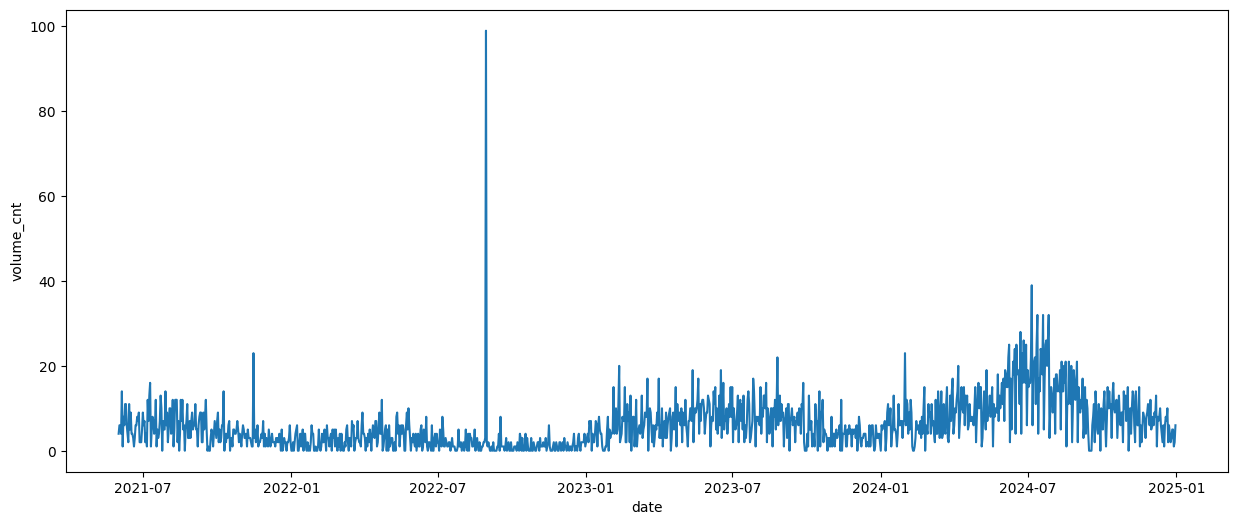

In [21]:
plt.figure(figsize=(15, 6))
# sns.lineplot(data=daily_apt_volume_df.query("region == '서울특별시 강남구'"), x='date', y='vzdi_30')
sns.lineplot(data=daily_apt_volume_df.query("region == '서울특별시 강남구'"), x='date', y='volume_cnt')
plt.show()

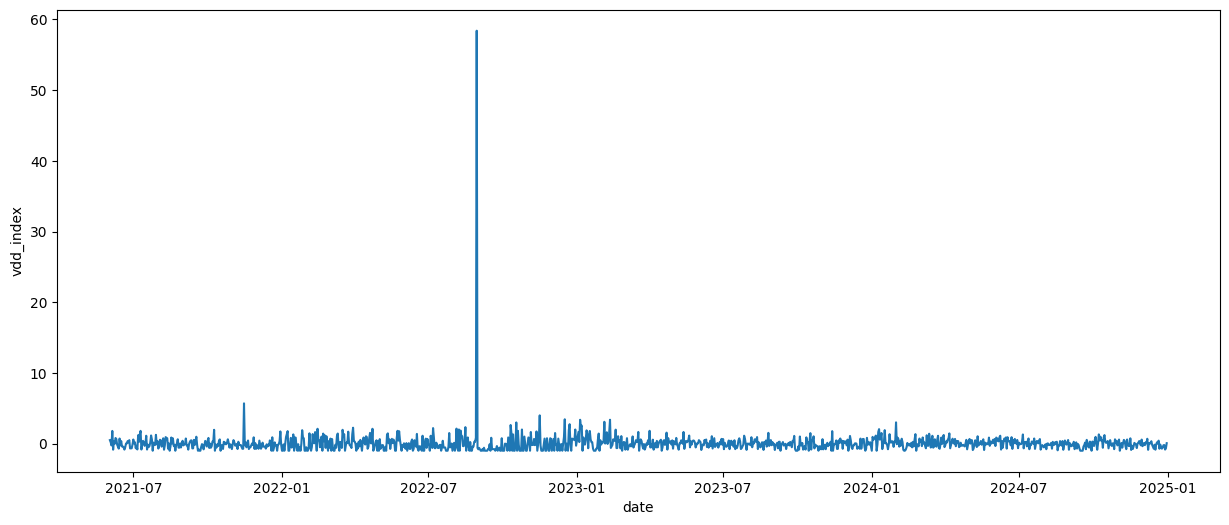

In [25]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_apt_volume_df.query("region == '서울특별시 강남구'"), x='date', y='vdd_index')
# sns.lineplot(data=daily_apt_volume_df.query("region == '서울특별시 강남구'"), x='date', y='volume_cnt')
plt.show()

In [12]:
# daily_apt_volume_df_202102 = daily_apt_volume_df.query("date >= '2021-02-01'")
# daily_apt_volume_df_202102.info()

In [18]:
daily_apt_volume_df.groupby('region')['date'].nunique()

region
서울특별시 강남구     1310
서울특별시 강동구     1310
서울특별시 강북구     1310
서울특별시 강서구     1310
서울특별시 관악구     1310
서울특별시 광진구     1310
서울특별시 구로구     1310
서울특별시 금천구     1310
서울특별시 노원구     1310
서울특별시 도봉구     1310
서울특별시 동대문구    1310
서울특별시 동작구     1310
서울특별시 마포구     1310
서울특별시 서대문구    1310
서울특별시 서초구     1310
서울특별시 성동구     1310
서울특별시 성북구     1310
서울특별시 송파구     1310
서울특별시 양천구     1310
서울특별시 영등포구    1310
서울특별시 용산구     1310
서울특별시 은평구     1310
서울특별시 종로구     1310
서울특별시 중구      1310
서울특별시 중랑구     1310
Name: date, dtype: int64

In [ ]:
# daily_apt_volume_df.to_excel(r'C:\lucio 서강대 정보통신대학원\학위논문\아파트 거래량 이상탐지\apt_volume_anomaly_detection\dataset\apt_volume\apt_purchase_volume_daily.xlsx')

In [21]:
daily_apt_volume_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32750 entries, 0 to 32749
Data columns (total 24 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   region                                           32750 non-null  object        
 1   date                                             32750 non-null  datetime64[ns]
 2   volume_cnt                                       32750 non-null  float64       
 3   cancel_cnt                                       32750 non-null  float64       
 4   register_cnt                                     32750 non-null  float64       
 5   avg_area_size                                    32750 non-null  float64       
 6   avg_sales                                        32750 non-null  float64       
 7   avg_floor_cnt                                    32750 non-null  float64       
 8   volume_cnt_max_before               

# 3. 아파트 전월세 거래량

In [22]:
# 행정구 / 일 단위 데이터셋 생성
apt_rent_volume_df_lst = []
for date_index in tqdm(date_index_lst):

    origin_apt_rent_volume_df = pd.read_excel(f'C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/apt_rent_volume/apt_rent_volume_{date_index}.xlsx', header=12)

    # 거래일자
    origin_apt_rent_volume_df['date'] = origin_apt_rent_volume_df['계약년월'].astype(str) + origin_apt_rent_volume_df['계약일'].astype(str)
    origin_apt_rent_volume_df['date'] = pd.to_datetime(origin_apt_rent_volume_df['date'], format='%Y%m%d')

    # 지역
    origin_apt_rent_volume_df['region'] = origin_apt_rent_volume_df['시군구'].map(lambda x: ' '.join(x.split(' ')[:2]))
    
    # 보증금
    origin_apt_rent_volume_df['보증금(만원)'] = origin_apt_rent_volume_df['보증금(만원)'].map(lambda x: int(str(x).replace(',', '')) * 10000)

    # 월세금
    origin_apt_rent_volume_df['월세금(만원)'] = origin_apt_rent_volume_df['월세금(만원)'].map(lambda x: int(str(x).replace(',', '')) * 10000)

    # 전용면적 컬럼명 변경
    origin_apt_rent_volume_df = origin_apt_rent_volume_df.rename(columns={'전용면적(㎡)':'size'})

    apt_rent_volume_df_lst.append(origin_apt_rent_volume_df)

apt_rent_volume_df = pd.concat(apt_rent_volume_df_lst, ignore_index=True)
apt_rent_volume_df

100%|██████████| 4/4 [07:31<00:00, 112.94s/it]


,NO,시군구,번지,본번,부번,단지명,전월세구분,size,계약년월,계약일,...,건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원),주택유형,date,region
0,1,서울특별시 용산구 한강로1가,216-11,216,11,센트럴파크,전세,27.8200,202205,31,...,2021,한강대로62길 45-25,202206~202406,신규,-,NaN,NaN,아파트,2022-05-31,서울특별시 용산구
1,2,서울특별시 용산구 효창동,288,288,0,용산데시앙포레,전세,59.7600,202205,31,...,2022,효창원로 227,202207~202407,신규,-,NaN,NaN,아파트,2022-05-31,서울특별시 용산구
2,3,서울특별시 종로구 숭인동,207-32,207,32,영하우스,월세,16.5900,202205,31,...,2015,난계로29길 55,202307~202507,신규,-,NaN,NaN,아파트,2022-05-31,서울특별시 종로구
3,4,서울특별시 종로구 숭인동,207-32,207,32,영하우스,월세,20.2700,202205,31,...,2015,난계로29길 55,-,-,-,NaN,NaN,아파트,2022-05-31,서울특별시 종로구
4,5,서울특별시 종로구 홍파동,199,199,0,경희궁자이(2단지),전세,59.8547,202205,31,...,2017,송월길 99,202206~202309,갱신,사용,"77,000",0,아파트,2022-05-31,서울특별시 종로구
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
929183,133900,서울특별시 금천구 가산동,769,769,0,두산,전세,84.9000,202406,1,...,1998,가산로 99,202407~202607,갱신,-,"32,800",0,아파트,2024-06-01,서울특별시 금천구
929184,133901,서울특별시 금천구 가산동,143-20,143,20,가산피어니빌,월세,21.0829,202406,1,...,2017,디지털로12길 37,202407~202607,신규,-,NaN,NaN,아파트,2024-06-01,서울특별시 금천구
929185,133902,서울특별시 강서구 방화동,832,832,0,청솔,전세,39.3600,202406,1,...,1994,방화대로47길 55,202407~202607,신규,-,NaN,NaN,아파트,2024-06-01,서울특별시 강서구
929186,133903,서울특별시 강서구 방화동,839,839,0,방화그린,전세,39.7600,202406,1,...,1993,방화대로48길 40,202407~202607,신규,-,NaN,NaN,아파트,2024-06-01,서울특별시 강서구


In [23]:
len(apt_rent_volume_df.query("date >= '2021-11-01'"))

828103

In [24]:
# 거래 발생 여부 컬럼 추가
apt_rent_volume_df['is_trade'] = 1

In [25]:
daily_apt_rent_volume_df = apt_rent_volume_df.groupby(['region', 'date', '전월세구분']).agg(
                                                            rent_volume_cnt=('is_trade', 'sum'),

                                                            avg_area_size=('size', 'mean'),
                                                            avg_sales=('보증금(만원)', 'mean'),
                                                            avg_monthly_sales=('월세금(만원)', 'mean'),
                                                            avg_floor_cnt=('층', 'mean'),

                                                        ).reset_index()

daily_apt_rent_volume_df = daily_apt_rent_volume_df.pivot(index=['region', 'date'], columns='전월세구분')

daily_apt_rent_volume_df.columns = ['_'.join(col).strip() for col in daily_apt_rent_volume_df.columns.values]
daily_apt_rent_volume_df = daily_apt_rent_volume_df.reset_index()

daily_apt_rent_volume_df = daily_apt_rent_volume_df.rename(columns={
    'rent_volume_cnt_전세': 'jeonse_volume_cnt',
    'avg_sales_전세': 'jeonse_avg_deposit',
    
    'rent_volume_cnt_월세': 'wolse_volume_cnt',
    'avg_sales_월세': 'wolse_avg_deposit',
    'avg_monthly_sales_월세': 'wolse_avg_monthly',
    
    'avg_area_size_전세': 'jeonse_avg_area_size',
    'avg_area_size_월세': 'wolse_avg_area_size',
    
    'avg_floor_cnt_전세': 'jeonse_avg_floor_cnt',
    'avg_floor_cnt_월세': 'wolse_avg_floor_cnt',
})

# 최종 결과
daily_apt_rent_volume_df = daily_apt_rent_volume_df.drop('avg_monthly_sales_전세', axis=1)
daily_apt_rent_volume_df

,region,date,wolse_volume_cnt,jeonse_volume_cnt,wolse_avg_area_size,jeonse_avg_area_size,wolse_avg_deposit,jeonse_avg_deposit,wolse_avg_monthly,wolse_avg_floor_cnt,jeonse_avg_floor_cnt
0,서울특별시 강남구,2021-06-01,17.0,38.0,73.470282,91.626521,2.491224e+08,9.806974e+08,1.221765e+06,8.117647,10.052632
1,서울특별시 강남구,2021-06-02,17.0,24.0,98.503035,89.297900,3.466765e+08,1.026219e+09,2.202353e+06,8.176471,7.750000
2,서울특별시 강남구,2021-06-03,21.0,24.0,73.613162,74.301650,4.675290e+08,8.035000e+08,1.933333e+06,10.666667,10.791667
3,서울특별시 강남구,2021-06-04,11.0,42.0,78.890991,79.828871,3.440909e+08,9.289048e+08,1.841818e+06,8.363636,8.119048
4,서울특별시 강남구,2021-06-05,33.0,63.0,84.004709,69.807259,5.493939e+08,6.962698e+08,1.714848e+06,9.181818,6.349206
...,...,...,...,...,...,...,...,...,...,...,...
32320,서울특별시 중랑구,2024-12-27,10.0,7.0,36.027900,77.217371,1.255810e+08,4.028571e+08,3.770000e+05,9.700000,8.142857
32321,서울특별시 중랑구,2024-12-28,10.0,17.0,51.611280,67.583547,9.180000e+07,4.061765e+08,7.700000e+05,7.800000,5.764706
32322,서울특별시 중랑구,2024-12-29,NaN,1.0,NaN,39.840000,NaN,2.400000e+08,NaN,NaN,8.000000
32323,서울특별시 중랑구,2024-12-30,8.0,5.0,50.877825,62.479200,1.746738e+08,3.820000e+08,4.750000e+05,6.375000,6.400000


In [26]:
# 날짜 펼치기
date_range = pd.date_range(start="2021-06-01", end="2024-12-31", freq="D")
daily_date_df = pd.DataFrame({"date": date_range})

districts = apt_rent_volume_df["region"].unique()

filled_apt_rent_volume_df_lst = []
for gu in districts:

    # 해당 구 데이터만 필터링
    gu_df = daily_apt_rent_volume_df[daily_apt_rent_volume_df["region"] == gu]

    # 날짜 DataFrame과 outer merge
    merged = pd.merge(daily_date_df, gu_df, on="date", how="left").fillna(0)

    # 'region' 결측값 채우기
    merged["region"] = gu

    # 리스트에 저장
    filled_apt_rent_volume_df_lst.append(merged)

# 5. 구별 데이터 모두 합치기
filled_apt_rent_volume_df = pd.concat(filled_apt_rent_volume_df_lst, ignore_index=True)
filled_apt_rent_volume_df

,date,region,wolse_volume_cnt,jeonse_volume_cnt,wolse_avg_area_size,jeonse_avg_area_size,wolse_avg_deposit,jeonse_avg_deposit,wolse_avg_monthly,wolse_avg_floor_cnt,jeonse_avg_floor_cnt
0,2021-06-01,서울특별시 용산구,3.0,10.0,97.035667,93.180000,1.333333e+08,6.868000e+08,1.866667e+06,20.666667,7.100000
1,2021-06-02,서울특별시 용산구,14.0,5.0,60.311671,72.034000,1.316500e+08,4.256000e+08,9.250000e+05,10.142857,6.200000
2,2021-06-03,서울특별시 용산구,3.0,8.0,79.716667,63.677500,3.083333e+08,5.150000e+08,5.100000e+05,12.666667,6.500000
3,2021-06-04,서울특별시 용산구,7.0,13.0,91.567443,85.665385,3.192914e+08,6.294615e+08,1.205714e+06,21.571429,10.384615
4,2021-06-05,서울특별시 용산구,11.0,27.0,79.559518,90.439004,1.654727e+08,7.044815e+08,1.759091e+06,9.909091,11.259259
...,...,...,...,...,...,...,...,...,...,...,...
32745,2024-12-27,서울특별시 마포구,16.0,16.0,61.636888,70.634606,2.043300e+08,5.937006e+08,1.081250e+06,9.187500,7.687500
32746,2024-12-28,서울특별시 마포구,16.0,26.0,75.612519,76.909850,3.175775e+08,6.942788e+08,1.196875e+06,13.000000,8.192308
32747,2024-12-29,서울특별시 마포구,1.0,5.0,84.597800,56.398000,5.000000e+08,4.260000e+08,8.300000e+05,2.000000,3.200000
32748,2024-12-30,서울특별시 마포구,22.0,24.0,58.286882,68.973117,1.903145e+08,4.499950e+08,7.704545e+05,8.545455,7.791667


In [27]:
filled_apt_rent_volume_df.groupby('region')['date'].nunique()

region
서울특별시 강남구     1310
서울특별시 강동구     1310
서울특별시 강북구     1310
서울특별시 강서구     1310
서울특별시 관악구     1310
서울특별시 광진구     1310
서울특별시 구로구     1310
서울특별시 금천구     1310
서울특별시 노원구     1310
서울특별시 도봉구     1310
서울특별시 동대문구    1310
서울특별시 동작구     1310
서울특별시 마포구     1310
서울특별시 서대문구    1310
서울특별시 서초구     1310
서울특별시 성동구     1310
서울특별시 성북구     1310
서울특별시 송파구     1310
서울특별시 양천구     1310
서울특별시 영등포구    1310
서울특별시 용산구     1310
서울특별시 은평구     1310
서울특별시 종로구     1310
서울특별시 중구      1310
서울특별시 중랑구     1310
Name: date, dtype: int64

In [29]:
final_daily_apt_volume_df = pd.merge(daily_apt_volume_df, filled_apt_rent_volume_df, on=['region', 'date'], how='inner')
final_daily_apt_volume_df.info()
# final_daily_apt_volume_df.to_excel(r'C:\lucio 서강대 정보통신대학원\학위논문\아파트 거래량 이상탐지\apt_volume_anomaly_detection\dataset\apt_volume\apt_volume_daily_total_201006_202412.xlsx', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32750 entries, 0 to 32749
Data columns (total 33 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   region                                           32750 non-null  object        
 1   date                                             32750 non-null  datetime64[ns]
 2   volume_cnt                                       32750 non-null  float64       
 3   cancel_cnt                                       32750 non-null  float64       
 4   register_cnt                                     32750 non-null  float64       
 5   avg_area_size                                    32750 non-null  float64       
 6   avg_sales                                        32750 non-null  float64       
 7   avg_floor_cnt                                    32750 non-null  float64       
 8   volume_cnt_max_before               

# 4. 연립/다세대 주택 매매 거래량

In [30]:
# 행정구 / 일 단위 데이터셋 생성
townhouse_volume_df_lst = []
for date_index in tqdm(date_index_lst):

    origin_townhouse_volume_df = pd.read_excel(f'C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/townhouse_volume/townhouse_purchase_volume_{date_index}.xlsx', header=12)

    # 거래일자
    origin_townhouse_volume_df['date'] = origin_townhouse_volume_df['계약년월'].astype(str) + origin_townhouse_volume_df['계약일'].astype(str)
    origin_townhouse_volume_df['date'] = pd.to_datetime(origin_townhouse_volume_df['date'], format='%Y%m%d')

    # 지역
    origin_townhouse_volume_df['region'] = origin_townhouse_volume_df['시군구'].map(lambda x: ' '.join(x.split(' ')[:2]))
    
    # 거래금액
    origin_townhouse_volume_df['거래금액(만원)'] = origin_townhouse_volume_df['거래금액(만원)'].map(lambda x: int(x.replace(',', '')) * 10000)

    # 계약 해지 여부
    origin_townhouse_volume_df['is_trade_canceled'] = origin_townhouse_volume_df['해제사유발생일'].map(lambda x: 1 if x != '-' else 0)

    # 해제사유발생일 도달 기간
    origin_townhouse_volume_df['해제사유발생일'] = pd.to_numeric(origin_townhouse_volume_df['해제사유발생일'], errors='coerce')
    origin_townhouse_volume_df['해제사유발생일'] = pd.to_datetime(origin_townhouse_volume_df['해제사유발생일'], format='%Y%m%d', errors='coerce')
    origin_townhouse_volume_df['trade_canceled_duration'] = (origin_townhouse_volume_df['해제사유발생일'] - origin_townhouse_volume_df['date']).dt.days

    # 전용면적 컬럼명 변경
    origin_townhouse_volume_df = origin_townhouse_volume_df.rename(columns={'전용면적(㎡)':'size'})

    townhouse_volume_df_lst.append(origin_townhouse_volume_df)

townhouse_volume_df = pd.concat(townhouse_volume_df_lst, ignore_index=True)
townhouse_volume_df

100%|██████████| 4/4 [00:46<00:00, 11.69s/it]


,NO,시군구,번지,본번,부번,건물명,size,대지권면적(㎡),계약년월,계약일,...,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,date,region,is_trade_canceled,trade_canceled_duration
0,1,서울특별시 종로구 명륜1가,5-25,5,25,(5-25),43.660,13.9800,202205,31,...,성균관로15가길 16-6,NaT,중개거래,서울 종로구,-,다세대,2022-05-31,서울특별시 종로구,0,NaN
1,2,서울특별시 도봉구 도봉동,573-25,573,25,진주15,41.550,33.1833,202205,31,...,도봉로181길 69,NaT,중개거래,서울 도봉구,-,다세대,2022-05-31,서울특별시 도봉구,0,NaN
2,3,서울특별시 중랑구 상봉동,136-90,136,90,마제스티,29.000,22.1400,202205,31,...,중랑천로10길 29-9,NaT,중개거래,서울 중랑구,-,다세대,2022-05-31,서울특별시 중랑구,0,NaN
3,4,서울특별시 성북구 장위동,230-103,230,103,송학누리안,51.730,28.8600,202205,31,...,장위로15길 25,2022-10-13,직거래,-,-,연립,2022-05-31,서울특별시 성북구,1,135.0
4,5,서울특별시 성동구 행당동,286-37,286,37,그린하우스,29.300,11.1000,202205,31,...,무학봉26길 19,NaT,직거래,-,-,다세대,2022-05-31,서울특별시 성동구,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114365,16635,서울특별시 서초구 양재동,5-9,5,9,비버리하임,58.010,27.4650,202406,1,...,논현로31길 65,NaT,중개거래,서울 강남구,24.06.14,다세대,2024-06-01,서울특별시 서초구,0,NaN
114366,16636,서울특별시 구로구 오류동,81-271,81,271,양지마을,55.400,30.2200,202406,1,...,경인로15나길 8,NaT,중개거래,서울 구로구,24.07.25,다세대,2024-06-01,서울특별시 구로구,0,NaN
114367,16637,서울특별시 동작구 상도동,214-24,214,24,삼도빌리지,26.330,21.9300,202406,1,...,양녕로22마길 23,NaT,중개거래,서울 동작구,24.07.26,다세대,2024-06-01,서울특별시 동작구,0,NaN
114368,16638,서울특별시 송파구 문정동,8-10,8,10,베루스송파,25.360,18.2300,202406,1,...,동남로8길 25-7,NaT,중개거래,서울 송파구,24.08.09,다세대,2024-06-01,서울특별시 송파구,0,NaN


In [31]:
len(townhouse_volume_df.query("date >= '2021-11-01'"))

89912

In [32]:
# 거래 발생 여부 컬럼 추가
townhouse_volume_df['is_trade'] = 1

daily_townhouse_volume_df = townhouse_volume_df.groupby(['region', 'date']).agg(
                                                            townhouse_volume_cnt=('is_trade', 'sum'),
                                                            # townhouse_cancel_cnt=('is_trade_canceled', 'sum'),

                                                            townhouse_avg_area_size=('size', 'mean'),
                                                            townhouse_avg_sales=('거래금액(만원)', 'mean'),
                                                            townhouse_avg_floor_cnt=('층', 'mean')
                                                        ).reset_index()

daily_townhouse_volume_df

,region,date,townhouse_volume_cnt,townhouse_avg_area_size,townhouse_avg_sales,townhouse_avg_floor_cnt
0,서울특별시 강남구,2021-06-01,16,33.386875,4.296562e+08,4.375000
1,서울특별시 강남구,2021-06-02,12,28.116667,4.989167e+08,3.416667
2,서울특별시 강남구,2021-06-03,2,63.615000,5.190000e+08,2.000000
3,서울특별시 강남구,2021-06-04,7,35.794286,4.743286e+08,2.285714
4,서울특별시 강남구,2021-06-05,7,39.823286,5.421429e+08,3.285714
...,...,...,...,...,...,...
25964,서울특별시 중랑구,2024-12-26,2,35.425000,3.175000e+08,3.000000
25965,서울특별시 중랑구,2024-12-27,2,31.605000,3.575000e+08,3.000000
25966,서울특별시 중랑구,2024-12-28,5,54.776000,2.860000e+08,3.200000
25967,서울특별시 중랑구,2024-12-30,4,36.855000,2.950000e+08,5.250000


In [33]:
daily_townhouse_volume_df.groupby('region').agg(
    min_date=('date', 'min'),
    max_date=('date', 'max')
)

,min_date,max_date
region,,
서울특별시 강남구,2021-06-01,2024-12-31
서울특별시 강동구,2021-06-01,2024-12-31
서울특별시 강북구,2021-06-01,2024-12-31
서울특별시 강서구,2021-06-01,2024-12-31
서울특별시 관악구,2021-06-01,2024-12-31
서울특별시 광진구,2021-06-01,2024-12-31
서울특별시 구로구,2021-06-01,2024-12-31
서울특별시 금천구,2021-06-01,2024-12-31
서울특별시 노원구,2021-06-01,2024-12-31


In [34]:
# 날짜 펼치기
date_range = pd.date_range(start="2021-06-01", end="2024-12-31", freq="D")
daily_date_df = pd.DataFrame({"date": date_range})

districts = townhouse_volume_df["region"].unique()

filled_townhouse_volume_df_lst = []
for gu in districts:

    # 해당 구 데이터만 필터링
    gu_df = daily_townhouse_volume_df[daily_townhouse_volume_df["region"] == gu]

    # 날짜 DataFrame과 outer merge
    merged = pd.merge(daily_date_df, gu_df, on="date", how="left").fillna(0)

    # 'region' 결측값 채우기
    merged["region"] = gu

    # 리스트에 저장
    filled_townhouse_volume_df_lst.append(merged)

# 5. 구별 데이터 모두 합치기
filled_townhouse_volume_df = pd.concat(filled_townhouse_volume_df_lst, ignore_index=True)
filled_townhouse_volume_df

,date,region,townhouse_volume_cnt,townhouse_avg_area_size,townhouse_avg_sales,townhouse_avg_floor_cnt
0,2021-06-01,서울특별시 종로구,1.0,59.870000,4.000000e+08,-1.000000
1,2021-06-02,서울특별시 종로구,3.0,49.533333,4.448333e+08,3.666667
2,2021-06-03,서울특별시 종로구,0.0,0.000000,0.000000e+00,0.000000
3,2021-06-04,서울특별시 종로구,1.0,72.740000,3.800000e+08,4.000000
4,2021-06-05,서울특별시 종로구,3.0,70.853333,5.673333e+08,2.333333
...,...,...,...,...,...,...
32745,2024-12-27,서울특별시 관악구,0.0,0.000000,0.000000e+00,0.000000
32746,2024-12-28,서울특별시 관악구,1.0,40.920000,1.480000e+08,1.000000
32747,2024-12-29,서울특별시 관악구,0.0,0.000000,0.000000e+00,0.000000
32748,2024-12-30,서울특별시 관악구,2.0,54.030000,2.200000e+08,1.500000


In [35]:
final_daily_volume_df = final_daily_apt_volume_df.merge(filled_townhouse_volume_df, on=['region', 'date'], how='inner')
final_daily_volume_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32750 entries, 0 to 32749
Data columns (total 37 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   region                                           32750 non-null  object        
 1   date                                             32750 non-null  datetime64[ns]
 2   volume_cnt                                       32750 non-null  float64       
 3   cancel_cnt                                       32750 non-null  float64       
 4   register_cnt                                     32750 non-null  float64       
 5   avg_area_size                                    32750 non-null  float64       
 6   avg_sales                                        32750 non-null  float64       
 7   avg_floor_cnt                                    32750 non-null  float64       
 8   volume_cnt_max_before               

# 5. 단독/다가구 주택 매매 거래량

In [36]:
# 행정구 / 일 단위 데이터셋 생성
familyhouse_volume_df_lst = []
for date_index in tqdm(date_index_lst):

    origin_familyhouse_volume_df = pd.read_excel(f'C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/single_multi_familyhouse_volume/familyhouse_purchase_volume_{date_index}.xlsx', header=12)

    # 거래일자
    origin_familyhouse_volume_df['date'] = origin_familyhouse_volume_df['계약년월'].astype(str) + origin_familyhouse_volume_df['계약일'].astype(str)
    origin_familyhouse_volume_df['date'] = pd.to_datetime(origin_familyhouse_volume_df['date'], format='%Y%m%d')

    # 지역
    origin_familyhouse_volume_df['region'] = origin_familyhouse_volume_df['시군구'].map(lambda x: ' '.join(x.split(' ')[:2]))
    
    # 거래금액
    origin_familyhouse_volume_df['거래금액(만원)'] = origin_familyhouse_volume_df['거래금액(만원)'].map(lambda x: int(x.replace(',', '')) * 10000)

    # 계약 해지 여부
    origin_familyhouse_volume_df['is_trade_canceled'] = origin_familyhouse_volume_df['해제사유발생일'].map(lambda x: 1 if x != '-' else 0)

    # 해제사유발생일 도달 기간
    origin_familyhouse_volume_df['해제사유발생일'] = pd.to_numeric(origin_familyhouse_volume_df['해제사유발생일'], errors='coerce')
    origin_familyhouse_volume_df['해제사유발생일'] = pd.to_datetime(origin_familyhouse_volume_df['해제사유발생일'], format='%Y%m%d', errors='coerce')
    origin_familyhouse_volume_df['trade_canceled_duration'] = (origin_familyhouse_volume_df['해제사유발생일'] - origin_familyhouse_volume_df['date']).dt.days

    # 전용면적 컬럼명 변경
    origin_familyhouse_volume_df = origin_familyhouse_volume_df.rename(columns={'연면적(㎡)':'size'})

    familyhouse_volume_df_lst.append(origin_familyhouse_volume_df)

familyhouse_volume_df = pd.concat(familyhouse_volume_df_lst, ignore_index=True)
familyhouse_volume_df

100%|██████████| 4/4 [00:05<00:00,  1.45s/it]


,NO,시군구,번지,주택유형,도로조건,size,대지면적(㎡),계약년월,계약일,거래금액(만원),...,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,date,region,is_trade_canceled,trade_canceled_duration
0,1,서울특별시 관악구 신림동,5**,단독,12m미만,222.63,167.6,202205,31,2020000000,...,-,1996.0,조원로12길,2022-07-18,중개거래,서울 관악구,2022-05-31,서울특별시 관악구,1,48.0
1,2,서울특별시 관악구 신림동,5**,다가구,12m미만,285.89,260.4,202205,31,2100000000,...,-,1992.0,조원로12길,NaT,중개거래,서울 관악구,2022-05-31,서울특별시 관악구,0,NaN
2,3,서울특별시 관악구 신림동,5**,다가구,12m미만,222.63,167.6,202205,31,2020000000,...,-,1996.0,조원로12길,NaT,중개거래,서울 관악구,2022-05-31,서울특별시 관악구,0,NaN
3,4,서울특별시 동대문구 용두동,1**,단독,12m미만,424.08,221.0,202205,31,2330000000,...,-,2012.0,왕산로19길,NaT,중개거래,서울 동대문구,2022-05-31,서울특별시 동대문구,0,NaN
4,5,서울특별시 서대문구 연희동,3**,다가구,8m미만,484.57,219.0,202205,31,2700000000,...,-,2002.0,연희로4길,NaT,중개거래,서울 마포구,2022-05-31,서울특별시 서대문구,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15576,2051,서울특별시 동작구 노량진동,2**,단독,8m미만,163.17,116.0,202406,1,1500000000,...,법인,1992.0,NaN,NaT,중개거래,서울 동작구,2024-06-01,서울특별시 동작구,0,NaN
15577,2052,서울특별시 강북구 미아동,2**,단독,8m미만,34.12,61.8,202406,1,200000000,...,개인,1967.0,솔매로39길,NaT,직거래,-,2024-06-01,서울특별시 강북구,0,NaN
15578,2053,서울특별시 마포구 망원동,5*,단독,8m미만,74.73,51.0,202406,1,1030000000,...,개인,1991.0,월드컵로19길,NaT,중개거래,서울 마포구,2024-06-01,서울특별시 마포구,0,NaN
15579,2054,서울특별시 강북구 미아동,6**,다가구,8m미만,149.76,109.0,202406,1,880000000,...,개인,1993.0,삼양로20길,NaT,중개거래,서울 강북구,2024-06-01,서울특별시 강북구,0,NaN


In [38]:
len(familyhouse_volume_df.query("date >= '2021-11-01'"))

11652

In [39]:
# 거래 발생 여부 컬럼 추가
familyhouse_volume_df['is_trade'] = 1

daily_familyhouse_volume_df = familyhouse_volume_df.groupby(['region', 'date']).agg(
                                                            familyhouse_volume_cnt=('is_trade', 'sum'),
                                                            # townhouse_cancel_cnt=('is_trade_canceled', 'sum'),

                                                            familyhouse_avg_area_size=('size', 'mean'),
                                                            familyhouse_avg_sales=('거래금액(만원)', 'mean'),
                                                            # familyhouse_avg_floor_cnt=('층', 'mean')
                                                        ).reset_index()

daily_familyhouse_volume_df

,region,date,familyhouse_volume_cnt,familyhouse_avg_area_size,familyhouse_avg_sales
0,서울특별시 강남구,2021-06-02,2,343.81,4.450000e+09
1,서울특별시 강남구,2021-06-03,1,494.34,3.650000e+09
2,서울특별시 강남구,2021-06-04,2,96.58,2.535000e+09
3,서울특별시 강남구,2021-06-05,1,320.90,5.300000e+09
4,서울특별시 강남구,2021-06-06,1,259.74,3.300000e+09
...,...,...,...,...,...
10143,서울특별시 중랑구,2024-12-16,2,162.05,2.502300e+08
10144,서울특별시 중랑구,2024-12-20,1,200.37,7.800000e+08
10145,서울특별시 중랑구,2024-12-23,1,145.42,7.000000e+08
10146,서울특별시 중랑구,2024-12-26,1,143.88,4.300000e+08


In [40]:
daily_familyhouse_volume_df.groupby('region').agg(
    min_date=('date', 'min'),
    max_date=('date', 'max')
)

,min_date,max_date
region,,
서울특별시 강남구,2021-06-02,2024-12-19
서울특별시 강동구,2021-06-01,2024-12-20
서울특별시 강북구,2021-06-01,2024-12-27
서울특별시 강서구,2021-06-05,2024-12-25
서울특별시 관악구,2021-06-04,2024-12-31
서울특별시 광진구,2021-06-01,2024-12-31
서울특별시 구로구,2021-06-01,2024-12-19
서울특별시 금천구,2021-06-02,2024-11-28
서울특별시 노원구,2021-06-01,2024-12-17


In [41]:
# 날짜 펼치기
date_range = pd.date_range(start="2021-06-01", end="2024-12-31", freq="D")
daily_date_df = pd.DataFrame({"date": date_range})

districts = daily_familyhouse_volume_df["region"].unique()

filled_familyhouse_volume_df_lst = []
for gu in districts:

    # 해당 구 데이터만 필터링
    gu_df = daily_familyhouse_volume_df[daily_familyhouse_volume_df["region"] == gu]

    # 날짜 DataFrame과 outer merge
    merged = pd.merge(daily_date_df, gu_df, on="date", how="left").fillna(0)

    # 'region' 결측값 채우기
    merged["region"] = gu

    # 리스트에 저장
    filled_familyhouse_volume_df_lst.append(merged)

# 5. 구별 데이터 모두 합치기
filled_familyhouse_volume_df = pd.concat(filled_familyhouse_volume_df_lst, ignore_index=True)
filled_familyhouse_volume_df

,date,region,familyhouse_volume_cnt,familyhouse_avg_area_size,familyhouse_avg_sales
0,2021-06-01,서울특별시 강남구,0.0,0.00,0.000000e+00
1,2021-06-02,서울특별시 강남구,2.0,343.81,4.450000e+09
2,2021-06-03,서울특별시 강남구,1.0,494.34,3.650000e+09
3,2021-06-04,서울특별시 강남구,2.0,96.58,2.535000e+09
4,2021-06-05,서울특별시 강남구,1.0,320.90,5.300000e+09
...,...,...,...,...,...
32745,2024-12-27,서울특별시 중랑구,0.0,0.00,0.000000e+00
32746,2024-12-28,서울특별시 중랑구,0.0,0.00,0.000000e+00
32747,2024-12-29,서울특별시 중랑구,0.0,0.00,0.000000e+00
32748,2024-12-30,서울특별시 중랑구,0.0,0.00,0.000000e+00


In [42]:
final_daily_volume_df2 = final_daily_volume_df.merge(filled_familyhouse_volume_df, on=['region', 'date'], how='inner')
final_daily_volume_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32750 entries, 0 to 32749
Data columns (total 40 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   region                                           32750 non-null  object        
 1   date                                             32750 non-null  datetime64[ns]
 2   volume_cnt                                       32750 non-null  float64       
 3   cancel_cnt                                       32750 non-null  float64       
 4   register_cnt                                     32750 non-null  float64       
 5   avg_area_size                                    32750 non-null  float64       
 6   avg_sales                                        32750 non-null  float64       
 7   avg_floor_cnt                                    32750 non-null  float64       
 8   volume_cnt_max_before               

# 6. 단독/다가구 주택 전월세 거래량

In [43]:
# 행정구 / 일 단위 데이터셋 생성
familyhouse_rent_volume_df_lst = []
for date_index in tqdm(date_index_lst):

    origin_familyhouse_rent_volume_df = pd.read_excel(f'C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/single_multi_familyhouse_rent_volume/familyhouse_rent_volume_{date_index}.xlsx', header=12)
    origin_familyhouse_rent_volume_df = origin_familyhouse_rent_volume_df.query("계약구분 == '신규'")

    # 거래일자
    origin_familyhouse_rent_volume_df['date'] = origin_familyhouse_rent_volume_df['계약년월'].astype(str) + origin_familyhouse_rent_volume_df['계약일'].astype(str)
    origin_familyhouse_rent_volume_df['date'] = pd.to_datetime(origin_familyhouse_rent_volume_df['date'], format='%Y%m%d')

    # 지역
    origin_familyhouse_rent_volume_df['region'] = origin_familyhouse_rent_volume_df['시군구'].map(lambda x: ' '.join(x.split(' ')[:2]))
    
    # 보증금
    origin_familyhouse_rent_volume_df['보증금(만원)'] = origin_familyhouse_rent_volume_df['보증금(만원)'].map(lambda x: int(str(x).replace(',', '')) * 10000)

    # 월세금
    origin_familyhouse_rent_volume_df['월세금(만원)'] = origin_familyhouse_rent_volume_df['월세금(만원)'].map(lambda x: int(str(x).replace(',', '')) * 10000)

    # 전용면적 컬럼명 변경
    origin_familyhouse_rent_volume_df = origin_familyhouse_rent_volume_df.rename(columns={'계약면적(㎡)':'size'})

    familyhouse_rent_volume_df_lst.append(origin_familyhouse_rent_volume_df)

familyhouse_rent_volume_df = pd.concat(familyhouse_rent_volume_df_lst, ignore_index=True)
familyhouse_rent_volume_df

100%|██████████| 4/4 [04:16<00:00, 64.03s/it]


,NO,시군구,번지,도로조건,size,전월세구분,계약년월,계약일,보증금(만원),월세금(만원),건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원),주택유형,date,region
0,1,서울특별시 용산구 서계동,3*,8m미만,134.45,전세,202205,31,390000000,0,1930.0,청파로73다길,202205~202405,신규,-,NaN,NaN,단독,2022-05-31,서울특별시 용산구
1,2,서울특별시 종로구 가회동,1**,8m미만,33.00,전세,202205,31,150000000,0,1998.0,북촌로8길,202205~202405,신규,-,NaN,NaN,다가구,2022-05-31,서울특별시 종로구
2,4,서울특별시 종로구 사직동,3**,8m미만,48.84,전세,202205,31,150000000,0,2008.0,송월1길,202206~202406,신규,-,NaN,NaN,단독,2022-05-31,서울특별시 종로구
3,5,서울특별시 종로구 무악동,4*,8m미만,33.00,월세,202205,31,10000000,500000,2004.0,통일로14길,202206~202406,신규,-,NaN,NaN,다가구,2022-05-31,서울특별시 종로구
4,6,서울특별시 용산구 이태원동,1**,8m미만,46.87,월세,202205,31,100000000,550000,1991.0,이태원로23길,202206~202406,신규,-,NaN,NaN,다가구,2022-05-31,서울특별시 용산구
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387625,78611,서울특별시 관악구 신림동,9*,12m미만,34.00,전세,202406,1,50000000,0,1991.0,복은길,202407~202607,신규,-,NaN,NaN,단독,2024-06-01,서울특별시 관악구
387626,78612,서울특별시 관악구 신림동,4**,8m미만,18.00,월세,202406,1,5000000,560000,2017.0,남부순환로163가길,202406~202606,신규,-,NaN,NaN,단독,2024-06-01,서울특별시 관악구
387627,78613,서울특별시 관악구 신림동,6**,8m미만,20.00,월세,202406,1,5000000,450000,NaN,법원단지13길,202406~202505,신규,-,NaN,NaN,다가구,2024-06-01,서울특별시 관악구
387628,78614,서울특별시 관악구 신림동,3**,8m미만,34.00,월세,202406,1,10000000,400000,NaN,양지11길,202406~202606,신규,-,NaN,NaN,다가구,2024-06-01,서울특별시 관악구


In [44]:
len(familyhouse_rent_volume_df.query("date >= '2021-11-01'"))

347115

In [45]:
# 거래 발생 여부 컬럼 추가
familyhouse_rent_volume_df['is_trade'] = 1

In [46]:
daily_familyhouse_rent_volume_df = familyhouse_rent_volume_df.groupby(['region', 'date', '전월세구분']).agg(
                                                            rent_volume_cnt=('is_trade', 'sum'),

                                                            avg_area_size=('size', 'mean'),
                                                            avg_sales=('보증금(만원)', 'mean'),
                                                            avg_monthly_sales=('월세금(만원)', 'mean'),

                                                        ).reset_index()

daily_familyhouse_rent_volume_df = daily_familyhouse_rent_volume_df.pivot(index=['region', 'date'], columns='전월세구분')

daily_familyhouse_rent_volume_df.columns = ['_'.join(col).strip() for col in daily_familyhouse_rent_volume_df.columns.values]
daily_familyhouse_rent_volume_df = daily_familyhouse_rent_volume_df.reset_index()

daily_familyhouse_rent_volume_df = daily_familyhouse_rent_volume_df.rename(columns={
    'rent_volume_cnt_전세': 'familyhouse_jeonse_volume_cnt',
    'avg_sales_전세': 'familyhouse_jeonse_avg_deposit',
    
    'rent_volume_cnt_월세': 'familyhouse_wolse_volume_cnt',
    'avg_sales_월세': 'familyhouse_wolse_avg_deposit',
    'avg_monthly_sales_월세': 'familyhouse_wolse_avg_monthly',
    
    'avg_area_size_전세': 'familyhouse_jeonse_avg_area_size',
    'avg_area_size_월세': 'familyhouse_wolse_avg_area_size',
    
    'avg_floor_cnt_전세': 'familyhouse_jeonse_avg_floor_cnt',
    'avg_floor_cnt_월세': 'familyhouse_wolse_avg_floor_cnt',
})

# 최종 결과
daily_familyhouse_rent_volume_df = daily_familyhouse_rent_volume_df.drop('avg_monthly_sales_전세', axis=1)
daily_familyhouse_rent_volume_df

,region,date,familyhouse_wolse_volume_cnt,familyhouse_jeonse_volume_cnt,familyhouse_wolse_avg_area_size,familyhouse_jeonse_avg_area_size,familyhouse_wolse_avg_deposit,familyhouse_jeonse_avg_deposit,familyhouse_wolse_avg_monthly
0,서울특별시 강남구,2021-06-01,2.0,3.0,38.765000,32.373333,4.000000e+07,1.650000e+08,740000.000000
1,서울특별시 강남구,2021-06-02,10.0,8.0,46.236000,45.956250,5.613000e+07,2.267500e+08,683000.000000
2,서울특별시 강남구,2021-06-03,10.0,1.0,35.728000,54.000000,2.950000e+07,2.940000e+08,700000.000000
3,서울특별시 강남구,2021-06-04,9.0,2.0,32.218889,31.120000,2.007222e+07,1.400000e+08,687777.777778
4,서울특별시 강남구,2021-06-05,11.0,4.0,35.213636,56.650000,2.727273e+07,2.750000e+08,666363.636364
...,...,...,...,...,...,...,...,...,...
31763,서울특별시 중랑구,2024-12-27,11.0,1.0,36.898182,35.000000,3.090909e+07,7.000000e+07,481818.181818
31764,서울특별시 중랑구,2024-12-28,20.0,3.0,29.452500,39.000000,2.255000e+07,7.666667e+07,484000.000000
31765,서울특별시 중랑구,2024-12-29,NaN,1.0,NaN,58.500000,NaN,1.400000e+08,NaN
31766,서울특별시 중랑구,2024-12-30,19.0,1.0,34.770526,38.050000,2.843684e+07,1.100000e+08,521052.631579


In [47]:
daily_familyhouse_rent_volume_df.groupby('region').agg(
    min_date=('date', 'min'),
    max_date=('date', 'max')
).sort_values('min_date')

,min_date,max_date
region,,
서울특별시 강남구,2021-06-01,2024-12-31
서울특별시 종로구,2021-06-01,2024-12-31
서울특별시 은평구,2021-06-01,2024-12-31
서울특별시 용산구,2021-06-01,2024-12-31
서울특별시 영등포구,2021-06-01,2024-12-31
서울특별시 양천구,2021-06-01,2024-12-31
서울특별시 송파구,2021-06-01,2024-12-31
서울특별시 성북구,2021-06-01,2024-12-31
서울특별시 성동구,2021-06-01,2024-12-31


In [48]:
# 날짜 펼치기
date_range = pd.date_range(start="2021-06-01", end="2024-12-31", freq="D")
daily_date_df = pd.DataFrame({"date": date_range})

districts = daily_familyhouse_rent_volume_df["region"].unique()

filled_familyhouse_rent_volume_df_lst = []
for gu in districts:

    # 해당 구 데이터만 필터링
    gu_df = daily_familyhouse_rent_volume_df[daily_familyhouse_rent_volume_df["region"] == gu]

    # 날짜 DataFrame과 outer merge
    merged = pd.merge(daily_date_df, gu_df, on="date", how="left").fillna(0)

    # 'region' 결측값 채우기
    merged["region"] = gu

    # 리스트에 저장
    filled_familyhouse_rent_volume_df_lst.append(merged)

# 5. 구별 데이터 모두 합치기
filled_familyhouse_rent_volume_df = pd.concat(filled_familyhouse_rent_volume_df_lst, ignore_index=True)
filled_familyhouse_rent_volume_df

,date,region,familyhouse_wolse_volume_cnt,familyhouse_jeonse_volume_cnt,familyhouse_wolse_avg_area_size,familyhouse_jeonse_avg_area_size,familyhouse_wolse_avg_deposit,familyhouse_jeonse_avg_deposit,familyhouse_wolse_avg_monthly
0,2021-06-01,서울특별시 강남구,2.0,3.0,38.765000,32.373333,4.000000e+07,1.650000e+08,740000.000000
1,2021-06-02,서울특별시 강남구,10.0,8.0,46.236000,45.956250,5.613000e+07,2.267500e+08,683000.000000
2,2021-06-03,서울특별시 강남구,10.0,1.0,35.728000,54.000000,2.950000e+07,2.940000e+08,700000.000000
3,2021-06-04,서울특별시 강남구,9.0,2.0,32.218889,31.120000,2.007222e+07,1.400000e+08,687777.777778
4,2021-06-05,서울특별시 강남구,11.0,4.0,35.213636,56.650000,2.727273e+07,2.750000e+08,666363.636364
...,...,...,...,...,...,...,...,...,...
32745,2024-12-27,서울특별시 중랑구,11.0,1.0,36.898182,35.000000,3.090909e+07,7.000000e+07,481818.181818
32746,2024-12-28,서울특별시 중랑구,20.0,3.0,29.452500,39.000000,2.255000e+07,7.666667e+07,484000.000000
32747,2024-12-29,서울특별시 중랑구,0.0,1.0,0.000000,58.500000,0.000000e+00,1.400000e+08,0.000000
32748,2024-12-30,서울특별시 중랑구,19.0,1.0,34.770526,38.050000,2.843684e+07,1.100000e+08,521052.631579


In [49]:
final_daily_volume_df3 = final_daily_volume_df2.merge(filled_familyhouse_rent_volume_df, on=['region', 'date'], how='inner')
final_daily_volume_df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32750 entries, 0 to 32749
Data columns (total 47 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   region                                           32750 non-null  object        
 1   date                                             32750 non-null  datetime64[ns]
 2   volume_cnt                                       32750 non-null  float64       
 3   cancel_cnt                                       32750 non-null  float64       
 4   register_cnt                                     32750 non-null  float64       
 5   avg_area_size                                    32750 non-null  float64       
 6   avg_sales                                        32750 non-null  float64       
 7   avg_floor_cnt                                    32750 non-null  float64       
 8   volume_cnt_max_before               

# 7. 오피스텔 매매 거래량

In [50]:
# 행정구 / 일 단위 데이터셋 생성
officehouse_volume_df_lst = []
for date_index in tqdm(date_index_lst):

    origin_officehouse_volume_df = pd.read_excel(f'C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/officehouse_volume/officehouse_purchase_volume_{date_index}.xlsx', header=12)

    # 거래일자
    origin_officehouse_volume_df['date'] = origin_officehouse_volume_df['계약년월'].astype(str) + origin_officehouse_volume_df['계약일'].astype(str)
    origin_officehouse_volume_df['date'] = pd.to_datetime(origin_officehouse_volume_df['date'], format='%Y%m%d')

    # 지역
    origin_officehouse_volume_df['region'] = origin_officehouse_volume_df['시군구'].map(lambda x: ' '.join(x.split(' ')[:2]))
    
    # 거래금액
    origin_officehouse_volume_df['거래금액(만원)'] = origin_officehouse_volume_df['거래금액(만원)'].map(lambda x: int(x.replace(',', '')) * 10000)

    # 계약 해지 여부
    origin_officehouse_volume_df['is_trade_canceled'] = origin_officehouse_volume_df['해제사유발생일'].map(lambda x: 1 if x != '-' else 0)

    # 해제사유발생일 도달 기간
    origin_officehouse_volume_df['해제사유발생일'] = pd.to_numeric(origin_officehouse_volume_df['해제사유발생일'], errors='coerce')
    origin_officehouse_volume_df['해제사유발생일'] = pd.to_datetime(origin_officehouse_volume_df['해제사유발생일'], format='%Y%m%d', errors='coerce')
    origin_officehouse_volume_df['trade_canceled_duration'] = (origin_officehouse_volume_df['해제사유발생일'] - origin_officehouse_volume_df['date']).dt.days

    # 전용면적 컬럼명 변경
    origin_officehouse_volume_df = origin_officehouse_volume_df.rename(columns={'전용면적(㎡)':'size'})

    officehouse_volume_df_lst.append(origin_officehouse_volume_df)

officehouse_volume_df = pd.concat(officehouse_volume_df_lst, ignore_index=True)
officehouse_volume_df

100%|██████████| 4/4 [00:17<00:00,  4.32s/it]


,NO,시군구,번지,본번,부번,단지명,size,계약년월,계약일,거래금액(만원),...,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,date,region,is_trade_canceled,trade_canceled_duration
0,1,서울특별시 강동구 천호동,166-66,166,66,은슬림,40.36,202205,31,431500000,...,-,2022.0,진황도로27가길 6-12,NaT,직거래,-,2022-05-31,서울특별시 강동구,0,NaN
1,2,서울특별시 강동구 천호동,166-66,166,66,은슬림,39.68,202205,31,422000000,...,-,2022.0,진황도로27가길 6-12,NaT,직거래,-,2022-05-31,서울특별시 강동구,0,NaN
2,3,서울특별시 강동구 천호동,166-66,166,66,은슬림,40.36,202205,31,429500000,...,-,2022.0,진황도로27가길 6-12,NaT,직거래,-,2022-05-31,서울특별시 강동구,0,NaN
3,4,서울특별시 강동구 천호동,166-66,166,66,은슬림,39.68,202205,31,420000000,...,-,2022.0,진황도로27가길 6-12,NaT,직거래,-,2022-05-31,서울특별시 강동구,0,NaN
4,5,서울특별시 강동구 천호동,166-66,166,66,은슬림,39.68,202205,31,413500000,...,-,2022.0,진황도로27가길 6-12,NaT,직거래,-,2022-05-31,서울특별시 강동구,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46553,6278,서울특별시 강서구 마곡동,795-5,795,5,마곡사이언스파크뷰,22.07,202406,1,140000000,...,개인,2016.0,마곡중앙6로 85,NaT,중개거래,서울 강서구,2024-06-01,서울특별시 강서구,0,NaN
46554,6279,서울특별시 관악구 봉천동,861-7,861,7,CO-OP RESIDENCE/서울대입구,27.54,202406,1,168500000,...,개인,2005.0,봉천로 472,NaT,중개거래,서울 관악구,2024-06-01,서울특별시 관악구,0,NaN
46555,6280,서울특별시 도봉구 창동,630-5,630,5,창동 투웨니퍼스트,29.26,202406,1,192000000,...,개인,2017.0,,NaT,중개거래,서울 도봉구,2024-06-01,서울특별시 도봉구,0,NaN
46556,6281,서울특별시 성동구 성수동1가,13-12,13,12,이에스에이리버하우스,39.15,202406,1,451000000,...,개인,2004.0,광나루로 190,NaT,중개거래,서울 성동구,2024-06-01,서울특별시 성동구,0,NaN


In [51]:
len(officehouse_volume_df.query("date >= '2021-11-01'"))

38577

In [52]:
# 거래 발생 여부 컬럼 추가
officehouse_volume_df['is_trade'] = 1

daily_officehouse_volume_df = officehouse_volume_df.groupby(['region', 'date']).agg(
                                                            officehouse_volume_cnt=('is_trade', 'sum'),
                                                            # townhouse_cancel_cnt=('is_trade_canceled', 'sum'),

                                                            officehouse_avg_area_size=('size', 'mean'),
                                                            officehouse_avg_sales=('거래금액(만원)', 'mean'),
                                                            officehouse_avg_floor_cnt=('층', 'mean')
                                                        ).reset_index()

daily_officehouse_volume_df

,region,date,officehouse_volume_cnt,officehouse_avg_area_size,officehouse_avg_sales,officehouse_avg_floor_cnt
0,서울특별시 강남구,2021-06-01,9,35.021111,3.191789e+08,7.000000
1,서울특별시 강남구,2021-06-02,1,42.460000,4.650000e+08,3.000000
2,서울특별시 강남구,2021-06-03,5,34.134000,2.474000e+08,8.000000
3,서울특별시 강남구,2021-06-04,4,33.237500,2.595000e+08,10.250000
4,서울특별시 강남구,2021-06-05,3,26.105000,3.036667e+08,9.000000
...,...,...,...,...,...,...
16579,서울특별시 중랑구,2024-12-13,1,64.180000,4.450000e+08,3.000000
16580,서울특별시 중랑구,2024-12-20,29,20.240000,2.180283e+08,7.862069
16581,서울특별시 중랑구,2024-12-23,3,49.503933,4.395833e+08,17.000000
16582,서울특별시 중랑구,2024-12-24,1,18.500000,1.070000e+08,14.000000


In [53]:
daily_officehouse_volume_df.groupby('region').agg(
    min_date=('date', 'min'),
    max_date=('date', 'max')
).sort_values('min_date')

,min_date,max_date
region,,
서울특별시 강남구,2021-06-01,2024-12-31
서울특별시 종로구,2021-06-01,2024-12-30
서울특별시 은평구,2021-06-01,2024-12-30
서울특별시 영등포구,2021-06-01,2024-12-31
서울특별시 양천구,2021-06-01,2024-12-30
서울특별시 송파구,2021-06-01,2024-12-31
서울특별시 서초구,2021-06-01,2024-12-31
서울특별시 서대문구,2021-06-01,2024-12-31
서울특별시 중구,2021-06-01,2024-12-30


In [54]:
# 날짜 펼치기
date_range = pd.date_range(start="2021-06-01", end="2024-12-31", freq="D")
daily_date_df = pd.DataFrame({"date": date_range})

districts = daily_officehouse_volume_df["region"].unique()

filled_officehouse_volume_df_lst = []
for gu in districts:

    # 해당 구 데이터만 필터링
    gu_df = daily_officehouse_volume_df[daily_officehouse_volume_df["region"] == gu]

    # 날짜 DataFrame과 outer merge
    merged = pd.merge(daily_date_df, gu_df, on="date", how="left").fillna(0)

    # 'region' 결측값 채우기
    merged["region"] = gu

    # 리스트에 저장
    filled_officehouse_volume_df_lst.append(merged)

# 5. 구별 데이터 모두 합치기
filled_officehouse_volume_df = pd.concat(filled_officehouse_volume_df_lst, ignore_index=True)
filled_officehouse_volume_df

,date,region,officehouse_volume_cnt,officehouse_avg_area_size,officehouse_avg_sales,officehouse_avg_floor_cnt
0,2021-06-01,서울특별시 강남구,9.0,35.021111,3.191789e+08,7.00
1,2021-06-02,서울특별시 강남구,1.0,42.460000,4.650000e+08,3.00
2,2021-06-03,서울특별시 강남구,5.0,34.134000,2.474000e+08,8.00
3,2021-06-04,서울특별시 강남구,4.0,33.237500,2.595000e+08,10.25
4,2021-06-05,서울특별시 강남구,3.0,26.105000,3.036667e+08,9.00
...,...,...,...,...,...,...
32745,2024-12-27,서울특별시 중랑구,2.0,43.700100,2.745000e+08,11.00
32746,2024-12-28,서울특별시 중랑구,0.0,0.000000,0.000000e+00,0.00
32747,2024-12-29,서울특별시 중랑구,0.0,0.000000,0.000000e+00,0.00
32748,2024-12-30,서울특별시 중랑구,0.0,0.000000,0.000000e+00,0.00


In [55]:
final_daily_volume_df4 = final_daily_volume_df3.merge(filled_officehouse_volume_df, on=['region', 'date'], how='inner')
final_daily_volume_df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32750 entries, 0 to 32749
Data columns (total 51 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   region                                           32750 non-null  object        
 1   date                                             32750 non-null  datetime64[ns]
 2   volume_cnt                                       32750 non-null  float64       
 3   cancel_cnt                                       32750 non-null  float64       
 4   register_cnt                                     32750 non-null  float64       
 5   avg_area_size                                    32750 non-null  float64       
 6   avg_sales                                        32750 non-null  float64       
 7   avg_floor_cnt                                    32750 non-null  float64       
 8   volume_cnt_max_before               

# 8. 오피스텔 전월세 거래량

In [56]:
# 행정구 / 일 단위 데이터셋 생성
officehouse_rent_volume_df_lst = []
for date_index in tqdm(date_index_lst):

    origin_officehouse_rent_volume_df = pd.read_excel(f'C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/officehouse_rent_volume/officehouse_rent_volume_{date_index}.xlsx', header=12)
    origin_officehouse_rent_volume_df = origin_officehouse_rent_volume_df.query("계약구분 == '신규'")

    # 거래일자
    origin_officehouse_rent_volume_df['date'] = origin_officehouse_rent_volume_df['계약년월'].astype(str) + origin_officehouse_rent_volume_df['계약일'].astype(str)
    origin_officehouse_rent_volume_df['date'] = pd.to_datetime(origin_officehouse_rent_volume_df['date'], format='%Y%m%d')

    # 지역
    origin_officehouse_rent_volume_df['region'] = origin_officehouse_rent_volume_df['시군구'].map(lambda x: ' '.join(x.split(' ')[:2]))
    
    # 보증금
    origin_officehouse_rent_volume_df['보증금(만원)'] = origin_officehouse_rent_volume_df['보증금(만원)'].map(lambda x: int(str(x).replace(',', '')) * 10000)

    # 월세금
    origin_officehouse_rent_volume_df['월세금(만원)'] = origin_officehouse_rent_volume_df['월세금(만원)'].map(lambda x: int(str(x).replace(',', '')) * 10000)

    # 전용면적 컬럼명 변경
    origin_officehouse_rent_volume_df = origin_officehouse_rent_volume_df.rename(columns={'전용면적(㎡)':'size'})

    officehouse_rent_volume_df_lst.append(origin_officehouse_rent_volume_df)

officehouse_rent_volume_df = pd.concat(officehouse_rent_volume_df_lst, ignore_index=True)
officehouse_rent_volume_df

100%|██████████| 4/4 [02:32<00:00, 38.03s/it]


,NO,시군구,번지,본번,부번,단지명,전월세구분,size,계약년월,계약일,...,층,건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원),date,region
0,1,서울특별시 도봉구 도봉동,62-1,62,1,도봉 엠블렘,전세,16.99,202205,31,...,11,2018.0,,202206~202406,신규,-,NaN,NaN,2022-05-31,서울특별시 도봉구
1,3,서울특별시 동대문구 장안동,374-1,374,1,장안현대벤처빌,월세,32.24,202205,31,...,19,2004.0,장한로 85,202206~202306,신규,-,NaN,NaN,2022-05-31,서울특별시 동대문구
2,4,서울특별시 강북구 번동,417-6,417,6,포르텔오피스텔,월세,25.60,202205,31,...,8,2004.0,한천로 1003,202206~202306,신규,-,NaN,NaN,2022-05-31,서울특별시 강북구
3,5,서울특별시 강북구 번동,448-7,448,7,강북중앙드림빌,월세,28.97,202205,31,...,2,2003.0,도봉로82길 24-1,202206~202406,신규,-,NaN,NaN,2022-05-31,서울특별시 강북구
4,10,서울특별시 동대문구 장안동,365-9,365,9,케이타워,전세,18.84,202205,31,...,4,2020.0,장한로 98,202206~202406,신규,-,NaN,NaN,2022-05-31,서울특별시 동대문구
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194633,46011,서울특별시 강서구 화곡동,24-39,24,39,자하클래식,월세,15.88,202406,1,...,6,2018.0,,202406~202506,신규,-,NaN,NaN,2024-06-01,서울특별시 강서구
194634,46014,서울특별시 구로구 오류동,46-2,46,2,아크로펠리스,월세,18.00,202406,1,...,2,2004.0,경인로20나길 36,202408~202608,신규,-,NaN,NaN,2024-06-01,서울특별시 구로구
194635,46015,서울특별시 영등포구 영등포동4가,443,443,0,영등포 센트럴 푸르지오 시티,월세,29.61,202406,1,...,9,2013.0,문래로 180,202406~202506,신규,-,NaN,NaN,2024-06-01,서울특별시 영등포구
194636,46016,서울특별시 금천구 시흥동,118-86,118,86,미림메르디앙,월세,33.21,202406,1,...,3,2017.0,금하로5길 22,202406~202605,신규,-,NaN,NaN,2024-06-01,서울특별시 금천구


In [57]:
len(officehouse_rent_volume_df.query("date >= '2021-11-01'"))

175716

In [58]:
# 거래 발생 여부 컬럼 추가
officehouse_rent_volume_df['is_trade'] = 1

In [59]:
daily_officehouse_rent_volume_df = officehouse_rent_volume_df.groupby(['region', 'date', '전월세구분']).agg(
                                                            rent_volume_cnt=('is_trade', 'sum'),

                                                            avg_area_size=('size', 'mean'),
                                                            avg_floor_cnt=('층', 'mean'),
                                                            avg_sales=('보증금(만원)', 'mean'),
                                                            avg_monthly_sales=('월세금(만원)', 'mean'),

                                                        ).reset_index()

daily_officehouse_rent_volume_df = daily_officehouse_rent_volume_df.pivot(index=['region', 'date'], columns='전월세구분')

daily_officehouse_rent_volume_df.columns = ['_'.join(col).strip() for col in daily_officehouse_rent_volume_df.columns.values]
daily_officehouse_rent_volume_df = daily_officehouse_rent_volume_df.reset_index()

daily_officehouse_rent_volume_df = daily_officehouse_rent_volume_df.rename(columns={
    'rent_volume_cnt_전세': 'officehouse_jeonse_volume_cnt',
    'avg_sales_전세': 'officehouse_jeonse_avg_deposit',
    
    'rent_volume_cnt_월세': 'officehouse_wolse_volume_cnt',
    'avg_sales_월세': 'officehouse_wolse_avg_deposit',
    'avg_monthly_sales_월세': 'officehouse_wolse_avg_monthly',
    
    'avg_area_size_전세': 'officehouse_jeonse_avg_area_size',
    'avg_area_size_월세': 'officehouse_wolse_avg_area_size',
    
    'avg_floor_cnt_전세': 'officehouse_jeonse_avg_floor_cnt',
    'avg_floor_cnt_월세': 'officehouse_wolse_avg_floor_cnt',
})

# 최종 결과
daily_officehouse_rent_volume_df = daily_officehouse_rent_volume_df.drop('avg_monthly_sales_전세', axis=1)
daily_officehouse_rent_volume_df

,region,date,officehouse_wolse_volume_cnt,officehouse_jeonse_volume_cnt,officehouse_wolse_avg_area_size,officehouse_jeonse_avg_area_size,officehouse_wolse_avg_floor_cnt,officehouse_jeonse_avg_floor_cnt,officehouse_wolse_avg_deposit,officehouse_jeonse_avg_deposit,officehouse_wolse_avg_monthly
0,서울특별시 강남구,2021-06-01,2.0,3.0,18.505000,38.196667,10.00,6.333333,1.000000e+07,2.983333e+08,970000.0
1,서울특별시 강남구,2021-06-02,1.0,4.0,24.770000,26.017500,4.00,9.500000,1.000000e+07,2.638750e+08,900000.0
2,서울특별시 강남구,2021-06-03,5.0,2.0,30.102000,36.160000,7.60,8.000000,1.800000e+07,2.150000e+08,1040000.0
3,서울특별시 강남구,2021-06-04,1.0,2.0,32.440000,25.130000,9.00,3.500000,1.000000e+07,2.898750e+08,650000.0
4,서울특별시 강남구,2021-06-05,3.0,4.0,21.063333,28.682500,6.00,10.750000,8.333333e+06,2.695000e+08,660000.0
...,...,...,...,...,...,...,...,...,...,...,...
28602,서울특별시 중랑구,2024-12-26,3.0,2.0,42.233333,20.540000,8.00,7.500000,2.700000e+07,1.495000e+08,1000000.0
28603,서울특별시 중랑구,2024-12-27,4.0,1.0,22.952500,24.230000,6.25,6.000000,8.750000e+06,1.962400e+08,555000.0
28604,서울특별시 중랑구,2024-12-28,6.0,1.0,18.630000,59.090000,11.00,9.000000,6.100000e+07,3.300000e+08,375000.0
28605,서울특별시 중랑구,2024-12-30,2.0,NaN,33.080000,NaN,11.00,NaN,2.000000e+07,NaN,750000.0


In [60]:
daily_officehouse_rent_volume_df.groupby('region').agg(
    min_date=('date', 'min'),
    max_date=('date', 'max')
).sort_values('min_date')

,min_date,max_date
region,,
서울특별시 강남구,2021-06-01,2024-12-31
서울특별시 종로구,2021-06-01,2024-12-31
서울특별시 은평구,2021-06-01,2024-12-31
서울특별시 용산구,2021-06-01,2024-12-31
서울특별시 영등포구,2021-06-01,2024-12-31
서울특별시 양천구,2021-06-01,2024-12-31
서울특별시 송파구,2021-06-01,2024-12-31
서울특별시 성북구,2021-06-01,2024-12-31
서울특별시 성동구,2021-06-01,2024-12-31


In [61]:
# 날짜 펼치기
date_range = pd.date_range(start="2021-06-01", end="2024-12-31", freq="D")
daily_date_df = pd.DataFrame({"date": date_range})

districts = daily_officehouse_rent_volume_df["region"].unique()

filled_officehouse_rent_volume_df_lst = []
for gu in districts:

    # 해당 구 데이터만 필터링
    gu_df = daily_officehouse_rent_volume_df[daily_officehouse_rent_volume_df["region"] == gu]

    # 날짜 DataFrame과 outer merge
    merged = pd.merge(daily_date_df, gu_df, on="date", how="left").fillna(0)

    # 'region' 결측값 채우기
    merged["region"] = gu

    # 리스트에 저장
    filled_officehouse_rent_volume_df_lst.append(merged)

# 5. 구별 데이터 모두 합치기
filled_officehouse_rent_volume_df = pd.concat(filled_officehouse_rent_volume_df_lst, ignore_index=True)
filled_officehouse_rent_volume_df

,date,region,officehouse_wolse_volume_cnt,officehouse_jeonse_volume_cnt,officehouse_wolse_avg_area_size,officehouse_jeonse_avg_area_size,officehouse_wolse_avg_floor_cnt,officehouse_jeonse_avg_floor_cnt,officehouse_wolse_avg_deposit,officehouse_jeonse_avg_deposit,officehouse_wolse_avg_monthly
0,2021-06-01,서울특별시 강남구,2.0,3.0,18.505000,38.196667,10.00,6.333333,1.000000e+07,2.983333e+08,970000.0
1,2021-06-02,서울특별시 강남구,1.0,4.0,24.770000,26.017500,4.00,9.500000,1.000000e+07,2.638750e+08,900000.0
2,2021-06-03,서울특별시 강남구,5.0,2.0,30.102000,36.160000,7.60,8.000000,1.800000e+07,2.150000e+08,1040000.0
3,2021-06-04,서울특별시 강남구,1.0,2.0,32.440000,25.130000,9.00,3.500000,1.000000e+07,2.898750e+08,650000.0
4,2021-06-05,서울특별시 강남구,3.0,4.0,21.063333,28.682500,6.00,10.750000,8.333333e+06,2.695000e+08,660000.0
...,...,...,...,...,...,...,...,...,...,...,...
32745,2024-12-27,서울특별시 중랑구,4.0,1.0,22.952500,24.230000,6.25,6.000000,8.750000e+06,1.962400e+08,555000.0
32746,2024-12-28,서울특별시 중랑구,6.0,1.0,18.630000,59.090000,11.00,9.000000,6.100000e+07,3.300000e+08,375000.0
32747,2024-12-29,서울특별시 중랑구,0.0,0.0,0.000000,0.000000,0.00,0.000000,0.000000e+00,0.000000e+00,0.0
32748,2024-12-30,서울특별시 중랑구,2.0,0.0,33.080000,0.000000,11.00,0.000000,2.000000e+07,0.000000e+00,750000.0


In [62]:
final_daily_volume_df5 = final_daily_volume_df4.merge(filled_officehouse_rent_volume_df, on=['region', 'date'], how='inner')
final_daily_volume_df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32750 entries, 0 to 32749
Data columns (total 60 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   region                                           32750 non-null  object        
 1   date                                             32750 non-null  datetime64[ns]
 2   volume_cnt                                       32750 non-null  float64       
 3   cancel_cnt                                       32750 non-null  float64       
 4   register_cnt                                     32750 non-null  float64       
 5   avg_area_size                                    32750 non-null  float64       
 6   avg_sales                                        32750 non-null  float64       
 7   avg_floor_cnt                                    32750 non-null  float64       
 8   volume_cnt_max_before               

# 9. 연립/다세대 주택 전월세 거래량

In [63]:
# 행정구 / 일 단위 데이터셋 생성
townhouse_rent_volume_df_lst = []
for date_index in tqdm(date_index_lst):

    origin_townhouse_rent_volume_df = pd.read_excel(f'C:/lucio 서강대 정보통신대학원/학위논문/아파트 거래량 이상탐지/apt_volume_anomaly_detection/dataset/townhouse_rent_volume/townhouse_rent_volume_{date_index}.xlsx', header=12)
    origin_townhouse_rent_volume_df = origin_townhouse_rent_volume_df.query("계약구분 == '신규'")

    # 거래일자
    origin_townhouse_rent_volume_df['date'] = origin_townhouse_rent_volume_df['계약년월'].astype(str) + origin_townhouse_rent_volume_df['계약일'].astype(str)
    origin_townhouse_rent_volume_df['date'] = pd.to_datetime(origin_townhouse_rent_volume_df['date'], format='%Y%m%d')

    # 지역
    origin_townhouse_rent_volume_df['region'] = origin_townhouse_rent_volume_df['시군구'].map(lambda x: ' '.join(x.split(' ')[:2]))
    
    # 보증금
    origin_townhouse_rent_volume_df['보증금(만원)'] = origin_townhouse_rent_volume_df['보증금(만원)'].map(lambda x: int(str(x).replace(',', '')) * 10000)

    # 월세금
    origin_townhouse_rent_volume_df['월세금(만원)'] = origin_townhouse_rent_volume_df['월세금(만원)'].map(lambda x: int(str(x).replace(',', '')) * 10000)

    # 전용면적 컬럼명 변경
    origin_townhouse_rent_volume_df = origin_townhouse_rent_volume_df.rename(columns={'전용면적(㎡)':'size'})

    townhouse_rent_volume_df_lst.append(origin_townhouse_rent_volume_df)

townhouse_rent_volume_df = pd.concat(townhouse_rent_volume_df_lst, ignore_index=True)
townhouse_rent_volume_df

100%|██████████| 4/4 [04:00<00:00, 60.22s/it]


,NO,시군구,번지,본번,부번,건물명,전월세구분,size,계약년월,계약일,...,건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원),주택유형,date,region
0,3,서울특별시 종로구 원서동,76-25,76,25,성화하우스,월세,18.36,202205,31,...,2002,창덕궁길 139,202206~202406,신규,-,NaN,NaN,다세대,2022-05-31,서울특별시 종로구
1,7,서울특별시 성동구 성수동2가,265-4,265,4,정안맨션3차,월세,56.88,202205,31,...,1983,뚝섬로13길 6,202205~202405,신규,-,NaN,NaN,연립다세대,2022-05-31,서울특별시 성동구
2,9,서울특별시 광진구 구의동,60-61,60,61,현대그랑빌,전세,70.20,202205,31,...,2004,천호대로136길 29,202207~202407,신규,-,NaN,NaN,다세대,2022-05-31,서울특별시 광진구
3,11,서울특별시 광진구 구의동,223-33,223,33,한우리(223-33),월세,12.20,202205,31,...,2012,구의로6길 12,202205~202405,신규,-,NaN,NaN,다세대,2022-05-31,서울특별시 광진구
4,14,서울특별시 용산구 후암동,60-11,60,11,주연하우스,전세,29.34,202205,31,...,2022,후암로30길 19,202206~202406,신규,-,NaN,NaN,다세대,2022-05-31,서울특별시 용산구
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321459,75894,서울특별시 서초구 반포동,72-8,72,8,민유빌딩,전세,105.06,202406,1,...,2002,서래로6길 17,202406~202606,신규,-,NaN,NaN,다세대,2024-06-01,서울특별시 서초구
321460,75895,서울특별시 서초구 반포동,72-8,72,8,민유빌딩,전세,105.06,202406,1,...,2002,서래로6길 17,202406~202606,신규,-,NaN,NaN,다세대,2024-06-01,서울특별시 서초구
321461,75896,서울특별시 관악구 봉천동,1595-10,1595,10,더퍼스트빌리지,월세,48.61,202406,1,...,2020,관악로6길 5,202407~202607,신규,-,NaN,NaN,다세대,2024-06-01,서울특별시 관악구
321462,75897,서울특별시 관악구 봉천동,1595-10,1595,10,더퍼스트빌리지,월세,48.61,202406,1,...,2020,관악로6길 5,202407~202607,신규,-,NaN,NaN,다세대,2024-06-01,서울특별시 관악구


In [65]:
len(townhouse_rent_volume_df.query("date >= '2021-11-01'"))

288156

In [66]:
# 거래 발생 여부 컬럼 추가
townhouse_rent_volume_df['is_trade'] = 1

In [67]:
daily_townhouse_rent_volume_df = townhouse_rent_volume_df.groupby(['region', 'date', '전월세구분']).agg(
                                                            rent_volume_cnt=('is_trade', 'sum'),

                                                            avg_area_size=('size', 'mean'),
                                                            avg_floor_cnt=('층', 'mean'),
                                                            avg_sales=('보증금(만원)', 'mean'),
                                                            avg_monthly_sales=('월세금(만원)', 'mean'),

                                                        ).reset_index()

daily_townhouse_rent_volume_df = daily_townhouse_rent_volume_df.pivot(index=['region', 'date'], columns='전월세구분')

daily_townhouse_rent_volume_df.columns = ['_'.join(col).strip() for col in daily_townhouse_rent_volume_df.columns.values]
daily_townhouse_rent_volume_df = daily_townhouse_rent_volume_df.reset_index()

daily_townhouse_rent_volume_df = daily_townhouse_rent_volume_df.rename(columns={
    'rent_volume_cnt_전세': 'townhouse_jeonse_volume_cnt',
    'avg_sales_전세': 'townhouse_jeonse_avg_deposit',
    
    'rent_volume_cnt_월세': 'townhouse_wolse_volume_cnt',
    'avg_sales_월세': 'townhouse_wolse_avg_deposit',
    'avg_monthly_sales_월세': 'townhouse_wolse_avg_monthly',
    
    'avg_area_size_전세': 'townhouse_jeonse_avg_area_size',
    'avg_area_size_월세': 'townhouse_wolse_avg_area_size',
    
    'avg_floor_cnt_전세': 'townhouse_jeonse_avg_floor_cnt',
    'avg_floor_cnt_월세': 'townhouse_wolse_avg_floor_cnt',
})

# 최종 결과
daily_townhouse_rent_volume_df = daily_townhouse_rent_volume_df.drop('avg_monthly_sales_전세', axis=1)
daily_townhouse_rent_volume_df

,region,date,townhouse_wolse_volume_cnt,townhouse_jeonse_volume_cnt,townhouse_wolse_avg_area_size,townhouse_jeonse_avg_area_size,townhouse_wolse_avg_floor_cnt,townhouse_jeonse_avg_floor_cnt,townhouse_wolse_avg_deposit,townhouse_jeonse_avg_deposit,townhouse_wolse_avg_monthly
0,서울특별시 강남구,2021-06-01,7.0,4.0,39.270000,45.847500,3.000000,3.000000,5.000000e+07,4.002500e+08,650000.000000
1,서울특별시 강남구,2021-06-02,9.0,7.0,48.917778,93.272857,2.444444,2.285714,4.888889e+07,5.961429e+08,988888.888889
2,서울특별시 강남구,2021-06-03,5.0,4.0,50.802000,46.860000,2.800000,2.250000,3.230000e+07,3.392500e+08,936000.000000
3,서울특별시 강남구,2021-06-04,8.0,4.0,35.641250,65.562500,2.000000,2.750000,5.000000e+07,3.462500e+08,750000.000000
4,서울특별시 강남구,2021-06-05,4.0,8.0,42.050000,49.211250,3.000000,2.250000,9.000000e+07,3.943125e+08,655000.000000
...,...,...,...,...,...,...,...,...,...,...,...
31360,서울특별시 중랑구,2024-12-27,7.0,4.0,35.072857,39.870000,4.285714,2.500000,8.886286e+07,2.125000e+08,468571.428571
31361,서울특별시 중랑구,2024-12-28,6.0,7.0,26.641667,46.384286,5.500000,5.571429,9.833333e+07,2.875714e+08,430000.000000
31362,서울특별시 중랑구,2024-12-29,3.0,1.0,30.816667,12.080000,4.333333,4.000000,1.896667e+08,1.200000e+08,60000.000000
31363,서울특별시 중랑구,2024-12-30,5.0,2.0,39.822000,21.915000,3.000000,3.000000,1.349940e+08,1.300000e+08,406000.000000


In [68]:
daily_townhouse_rent_volume_df.groupby('region').agg(
    min_date=('date', 'min'),
    max_date=('date', 'max')
).sort_values('min_date')

,min_date,max_date
region,,
서울특별시 강남구,2021-06-01,2024-12-31
서울특별시 종로구,2021-06-01,2024-12-31
서울특별시 은평구,2021-06-01,2024-12-31
서울특별시 용산구,2021-06-01,2024-12-31
서울특별시 영등포구,2021-06-01,2024-12-31
서울특별시 양천구,2021-06-01,2024-12-31
서울특별시 송파구,2021-06-01,2024-12-31
서울특별시 성북구,2021-06-01,2024-12-31
서울특별시 성동구,2021-06-01,2024-12-31


In [69]:
# 날짜 펼치기
date_range = pd.date_range(start="2021-06-01", end="2024-12-31", freq="D")
daily_date_df = pd.DataFrame({"date": date_range})

districts = daily_townhouse_rent_volume_df["region"].unique()

filled_townhouse_rent_volume_df_lst = []
for gu in districts:

    # 해당 구 데이터만 필터링
    gu_df = daily_townhouse_rent_volume_df[daily_townhouse_rent_volume_df["region"] == gu]

    # 날짜 DataFrame과 outer merge
    merged = pd.merge(daily_date_df, gu_df, on="date", how="left").fillna(0)

    # 'region' 결측값 채우기
    merged["region"] = gu

    # 리스트에 저장
    filled_townhouse_rent_volume_df_lst.append(merged)

# 5. 구별 데이터 모두 합치기
filled_townhouse_rent_volume_df = pd.concat(filled_townhouse_rent_volume_df_lst, ignore_index=True)
filled_townhouse_rent_volume_df

,date,region,townhouse_wolse_volume_cnt,townhouse_jeonse_volume_cnt,townhouse_wolse_avg_area_size,townhouse_jeonse_avg_area_size,townhouse_wolse_avg_floor_cnt,townhouse_jeonse_avg_floor_cnt,townhouse_wolse_avg_deposit,townhouse_jeonse_avg_deposit,townhouse_wolse_avg_monthly
0,2021-06-01,서울특별시 강남구,7.0,4.0,39.270000,45.847500,3.000000,3.000000,5.000000e+07,4.002500e+08,650000.000000
1,2021-06-02,서울특별시 강남구,9.0,7.0,48.917778,93.272857,2.444444,2.285714,4.888889e+07,5.961429e+08,988888.888889
2,2021-06-03,서울특별시 강남구,5.0,4.0,50.802000,46.860000,2.800000,2.250000,3.230000e+07,3.392500e+08,936000.000000
3,2021-06-04,서울특별시 강남구,8.0,4.0,35.641250,65.562500,2.000000,2.750000,5.000000e+07,3.462500e+08,750000.000000
4,2021-06-05,서울특별시 강남구,4.0,8.0,42.050000,49.211250,3.000000,2.250000,9.000000e+07,3.943125e+08,655000.000000
...,...,...,...,...,...,...,...,...,...,...,...
32745,2024-12-27,서울특별시 중랑구,7.0,4.0,35.072857,39.870000,4.285714,2.500000,8.886286e+07,2.125000e+08,468571.428571
32746,2024-12-28,서울특별시 중랑구,6.0,7.0,26.641667,46.384286,5.500000,5.571429,9.833333e+07,2.875714e+08,430000.000000
32747,2024-12-29,서울특별시 중랑구,3.0,1.0,30.816667,12.080000,4.333333,4.000000,1.896667e+08,1.200000e+08,60000.000000
32748,2024-12-30,서울특별시 중랑구,5.0,2.0,39.822000,21.915000,3.000000,3.000000,1.349940e+08,1.300000e+08,406000.000000


In [70]:
final_daily_volume_df6 = final_daily_volume_df5.merge(filled_townhouse_rent_volume_df, on=['region', 'date'], how='inner')
final_daily_volume_df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32750 entries, 0 to 32749
Data columns (total 69 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   region                                           32750 non-null  object        
 1   date                                             32750 non-null  datetime64[ns]
 2   volume_cnt                                       32750 non-null  float64       
 3   cancel_cnt                                       32750 non-null  float64       
 4   register_cnt                                     32750 non-null  float64       
 5   avg_area_size                                    32750 non-null  float64       
 6   avg_sales                                        32750 non-null  float64       
 7   avg_floor_cnt                                    32750 non-null  float64       
 8   volume_cnt_max_before               

In [71]:
final_daily_volume_df6.query("date >= '2011-01-01'").groupby('region')['date'].nunique()

region
서울특별시 강남구     1310
서울특별시 강동구     1310
서울특별시 강북구     1310
서울특별시 강서구     1310
서울특별시 관악구     1310
서울특별시 광진구     1310
서울특별시 구로구     1310
서울특별시 금천구     1310
서울특별시 노원구     1310
서울특별시 도봉구     1310
서울특별시 동대문구    1310
서울특별시 동작구     1310
서울특별시 마포구     1310
서울특별시 서대문구    1310
서울특별시 서초구     1310
서울특별시 성동구     1310
서울특별시 성북구     1310
서울특별시 송파구     1310
서울특별시 양천구     1310
서울특별시 영등포구    1310
서울특별시 용산구     1310
서울특별시 은평구     1310
서울특별시 종로구     1310
서울특별시 중구      1310
서울특별시 중랑구     1310
Name: date, dtype: int64

In [72]:
final_daily_volume_df6.to_excel(r'C:\lucio 서강대 정보통신대학원\학위논문\아파트 거래량 이상탐지\apt_volume_anomaly_detection\dataset\apt_volume_daily_all_total_register_202106_202412.xlsx', index=False)